# ZTF g-band LOO cleaning and DRW D vs Lbol (SDSS+Gaia+Wushen VAC 2024)

This notebook:
1. Loads the augmented catalog `sdss_gaia_catalog_for_ztf_gaia_lc_with_wushen_vac_2024.fits`
2. Selects a user-defined redshift slice (e.g. `1 < z < 1.1`)
3. Loads matching ZTF g-band lightcurves (`ztf_g_for_gaia_primary.fits`)
4. Applies an S/N cut on lightcurves to reduce the sample size
5. Runs LOO outlier cleaning (parallel) and stores DRW fit results + removed epoch indices
6. Plots `log(D)` vs `logLbol` and color-codes by `log(M_BH)`

Where `D = sigma^2 / tau` from the DRW/OU GP fit.


In [39]:
import os
import numpy as np

# -----------------
# User parameters
# -----------------
Z_MIN = 1.0
Z_MAX = 1.1

# Keep only lightcurves with MIN_POINTS <= N_epochs <= MAX_EPOCHS.
# (This is important because the LOO algorithm is O(N_epochs^2) per object.)
MIN_POINTS = 10
MAX_EPOCHS = 2000

# Lightcurve S/N cut:
#   S = (95th - 5th) percentile of g-band mag
#   N = median mag error
# Keep if S/N > threshold.
SN_THRESHOLD = 5.0

# If too many objects pass the cut, increase threshold until <= TARGET_MAX.
# If too few objects pass the cut, decrease threshold until >= TARGET_MIN.
TARGET_MIN = 1000
TARGET_MAX = 3000

# LOO settings
BAND = 'g'
MAX_PASSES = 5
N_JOBS = -1   # joblib parallelism (set -1 to use all cores)
JOBLIB_PREFER = 'processes'  # set to 'processes' for CPU-bound work
JOBLIB_VERBOSE = 0          # joblib verbosity (0=silent, 10=chatty)
PROGRESS_CHUNK_SIZE = 100  # run LOO in chunks and report progress

# Debug/controls
RUN_LOO = True
WRITE_SELECTION = True
WRITE_RESULTS = True

# Read precomputed results (skip selection/LOO)
READ_RESULTS = False
RESULTS_TAG = None  # e.g. "z1.00_1.20_n10-2000_sn5.0_g"
RESULTS_FITS_OVERRIDE = None  # full path override
SELECTION_FITS_OVERRIDE = None
SN_THRESHOLD_TUNED = None  # set when tuning or when loading results


# If not None, cap the number of lightcurves sent to LOO (random subset).
MAX_OBJECTS_FOR_LOO = None
RANDOM_SEED = 0

# Inputs
CATALOG_PATH = os.path.expanduser('data/sdss_gaia_catalog_for_ztf_gaia_lc_with_wushen_vac_2024.fits')
ZTF_G_PATH = os.path.expanduser('data/ztf_g_for_gaia_primary.fits')

# Outputs
OUT_DIR = os.path.expanduser('data/loo_analysis')
os.makedirs(OUT_DIR, exist_ok=True)


In [40]:
from astropy.table import Table
import os

def _build_tag(z_min, z_max, min_points, max_epochs, sn_thr, band):
    return f"z{z_min:.2f}_{z_max:.2f}_n{min_points}-{max_epochs}_sn{sn_thr:.1f}_{band}"

if READ_RESULTS:
    if RESULTS_FITS_OVERRIDE:
        RESULTS_FITS = os.path.expanduser(RESULTS_FITS_OVERRIDE)
        TAG = RESULTS_TAG
    else:
        if SN_THRESHOLD_TUNED is None:
            # Fallback for naming; update if you know the tuned value.
            SN_THRESHOLD_TUNED = SN_THRESHOLD
        TAG = RESULTS_TAG or _build_tag(Z_MIN, Z_MAX, MIN_POINTS, MAX_EPOCHS, SN_THRESHOLD_TUNED, BAND)
        RESULTS_FITS = os.path.join(OUT_DIR, f"loo_results_{TAG}.fits")

    results_table = Table.read(RESULTS_FITS)
    print("Loaded results:", RESULTS_FITS, "rows:", len(results_table))

    # Optional selection metadata
    if SELECTION_FITS_OVERRIDE:
        SELECTION_FITS = os.path.expanduser(SELECTION_FITS_OVERRIDE)
    else:
        SELECTION_FITS = os.path.join(OUT_DIR, f"selection_{TAG}.fits")
    if os.path.exists(SELECTION_FITS):
        try:
            sel = Table.read(SELECTION_FITS)
            print("Loaded selection:", SELECTION_FITS, "rows:", len(sel))
        except Exception as e:
            print("Selection read failed:", type(e).__name__, e)
    else:
        print("Selection FITS not found:", SELECTION_FITS)


In [41]:
if READ_RESULTS:
    print('READ_RESULTS=True -> skipping catalog/ztf load')
else:
    from astropy.table import Table
    
    # Load catalog (memmap) then subset columns
    cat_full = Table.read(CATALOG_PATH, memmap=True)
    need_cat_cols = ['sdss_name', 'source_id', 'z', 'wushen_loglbol', 'wushen_logmbh']
    cat = cat_full[need_cat_cols]
    print('Catalog rows:', len(cat))
    
    # Basic filters
    m = np.isfinite(cat['z'])
    m &= (cat['z'] >= Z_MIN) & (cat['z'] < Z_MAX)
    m &= np.isfinite(cat['wushen_loglbol'])
    m &= np.isfinite(cat['wushen_logmbh'])
    
    cat_z = cat[m]
    print('Rows in z-slice:', len(cat_z))
    
    # Load ZTF g (memmap) then subset columns
    ztf_full = Table.read(ZTF_G_PATH, memmap=True)
    need_ztf_cols = ['sdss_name', 'ra', 'dec', 'mjd', 'mag', 'magerr', 'n_epochs_clean']
    ztf_g = ztf_full[need_ztf_cols]
    print('ZTF g rows:', len(ztf_g))


Catalog rows: 219830
Rows in z-slice: 11039
ZTF g rows: 217615


In [42]:
if READ_RESULTS:
    print('READ_RESULTS=True -> skipping catalog/ztf join')
else:
    from astropy.table import join
    
    # Join catalog slice to ZTF g by sdss_name (keeps only objects that have ZTF g data)
    
    # Ensure sdss_name are comparable plain strings
    cat_names_list = [str(x).strip() for x in cat_z['sdss_name']]
    ztf_names_list = [str(x).strip() for x in ztf_g['sdss_name']]
    max_len = max([1] + [len(s) for s in cat_names_list] + [len(s) for s in ztf_names_list])
    
    cat_z = cat_z.copy()
    cat_z['sdss_name'] = np.array(cat_names_list, dtype=f'U{max_len}')
    
    ztf_g = ztf_g.copy()
    ztf_g['sdss_name'] = np.array(ztf_names_list, dtype=f'U{max_len}')
    
    # Inner join
    j = join(cat_z, ztf_g, keys='sdss_name', join_type='inner')
    print('Matched rows (z-slice ∩ ZTF g):', len(j))
    
    # Rename ZTF columns to the format expected by apply_loo_cleaning.py
    j['mjd_g'] = j['mjd']
    j['mag_g'] = j['mag']
    j['magerr_g'] = j['magerr']
    
    # Drop the old names (keep the new ones)
    j.remove_columns(['mjd', 'mag', 'magerr'])
    
    # Epoch-count filter (important for LOO runtime)
    n_epochs = np.array(j['n_epochs_clean'], dtype=int)
    j = j[(n_epochs >= MIN_POINTS) & (n_epochs <= MAX_EPOCHS)]
    print(f'After epoch-count cut ({MIN_POINTS}..{MAX_EPOCHS}):', len(j))


Matched rows (z-slice ∩ ZTF g): 10934
After epoch-count cut (10..2000): 10815


In [43]:
if READ_RESULTS:
    print('READ_RESULTS=True -> skipping S/N selection')
else:
    # Compute lightcurve S/N per object
    
    def lc_sn(mag, magerr):
        mag = np.asarray(mag, dtype=float)
        magerr = np.asarray(magerr, dtype=float)
        ok = np.isfinite(mag) & np.isfinite(magerr) & (magerr > 0)
        if ok.sum() < MIN_POINTS:
            return np.nan
        s = np.nanpercentile(mag[ok], 95) - np.nanpercentile(mag[ok], 5)
        n = np.nanmedian(magerr[ok])
        if not np.isfinite(s) or not np.isfinite(n) or n <= 0:
            return np.nan
        return s / n
    
    sn = np.array([lc_sn(j['mag_g'][i], j['magerr_g'][i]) for i in range(len(j))], dtype=float)
    j['sn_lc'] = sn
    
    # Auto-tune threshold into [TARGET_MIN, TARGET_MAX]
    thr = float(SN_THRESHOLD)
    for _ in range(50):
        keep = np.isfinite(j['sn_lc']) & (j['sn_lc'] > thr)
        n_keep = int(keep.sum())
        if n_keep > TARGET_MAX:
            thr += 0.5
            continue
        if n_keep < TARGET_MIN and thr > 0.5:
            thr = max(0.5, thr - 0.5)
            continue
        break
    
    SN_THRESHOLD_TUNED = thr
    sel = j[np.isfinite(j['sn_lc']) & (j['sn_lc'] > SN_THRESHOLD_TUNED)]
    print('Tuned S/N threshold:', SN_THRESHOLD_TUNED)
    print('Selected for LOO:', len(sel))
    
    # Define output paths using the tuned threshold
    TAG = f"z{Z_MIN:.2f}_{Z_MAX:.2f}_n{MIN_POINTS}-{MAX_EPOCHS}_sn{SN_THRESHOLD_TUNED:.1f}_{BAND}"
    RESULTS_FITS = os.path.join(OUT_DIR, f"loo_results_{TAG}.fits")
    REMOVED_FITS = os.path.join(OUT_DIR, f"loo_removed_indices_{TAG}.fits")
    SELECTION_FITS = os.path.join(OUT_DIR, f"selection_{TAG}.fits")
    
    # Save the selection (so results are reproducible)
    sel['z_slice'] = np.full(len(sel), f"{Z_MIN}<=z<{Z_MAX}")
    sel['sn_threshold'] = np.full(len(sel), SN_THRESHOLD_TUNED)
    
    if WRITE_SELECTION:
        sel.write(SELECTION_FITS, overwrite=True)
        print('Wrote:', SELECTION_FITS)
    else:
        print('WRITE_SELECTION=False -> not writing selection FITS')


Tuned S/N threshold: 7.0
Selected for LOO: 2517
Wrote: data/loo_analysis/selection_z1.00_1.10_n10-2000_sn7.0_g.fits


In [44]:
if READ_RESULTS:
    print('READ_RESULTS=True -> skipping LOO run')
else:
    # Run LOO cleaning on ZTF g-band (parallel)
    import time
    from astropy.table import Table, join
    from joblib import Parallel, delayed
    from tqdm.auto import tqdm
    
    from apply_loo_cleaning import _ztf_loo_process_one
    
    if not RUN_LOO:
        print('RUN_LOO=False -> skipping expensive LOO step')
    else:
        sel_run = sel
        if MAX_OBJECTS_FOR_LOO is not None and len(sel_run) > int(MAX_OBJECTS_FOR_LOO):
            rng = np.random.default_rng(RANDOM_SEED)
            take = rng.choice(len(sel_run), size=int(MAX_OBJECTS_FOR_LOO), replace=False)
            sel_run = sel_run[np.sort(take)]
            print(f'Capped selection for LOO: {len(sel_run)} objects')
    
        # Build minimal tables expected by _ztf_loo_process_one
        ztf_loo = Table()
        ztf_loo['source_id'] = sel_run['source_id']
        ztf_loo['ra'] = sel_run['ra']
        ztf_loo['dec'] = sel_run['dec']
        ztf_loo['mjd_g'] = sel_run['mjd_g']
        ztf_loo['mag_g'] = sel_run['mag_g']
        ztf_loo['magerr_g'] = sel_run['magerr_g']
    
        cat_loo = Table()
        cat_loo['source_id'] = sel_run['source_id']
        cat_loo['z'] = sel_run['z']
    
        assert np.all(ztf_loo['source_id'] == cat_loo['source_id'])
    
        indices = np.arange(len(ztf_loo))
    
        def run_one(i):
            return _ztf_loo_process_one(i, ztf_loo, cat_loo, band=BAND, min_points=MIN_POINTS, max_passes=MAX_PASSES)
    
        n_jobs = N_JOBS if (N_JOBS is not None) else -1
        prefer = JOBLIB_PREFER
        print(f"Running LOO for {len(indices)} objects, band={BAND}, n_jobs={n_jobs}, prefer={prefer}")
    
        results = []
        removed_rows = []
    
        t0 = time.time()
        pbar = tqdm(total=len(indices), desc='LOO fits', unit='lc')
    
        # Run in chunks so we can print/monitor progress cleanly
        for i0 in range(0, len(indices), int(PROGRESS_CHUNK_SIZE)):
            i1 = min(i0 + int(PROGRESS_CHUNK_SIZE), len(indices))
            chunk = indices[i0:i1]
    
            try:
                outs = Parallel(n_jobs=n_jobs, prefer=prefer, verbose=JOBLIB_VERBOSE)(
                    delayed(run_one)(i) for i in chunk
                )
            except Exception as e:
                # If process-based backend fails on this system, fall back to threads.
                if prefer != 'threads':
                    print(f"Parallel backend '{prefer}' failed with {type(e).__name__}: {e}")
                    print("Falling back to threads; set JOBLIB_PREFER='threads' to silence this.")
                    prefer = 'threads'
                    outs = Parallel(n_jobs=n_jobs, prefer=prefer, verbose=JOBLIB_VERBOSE)(
                        delayed(run_one)(i) for i in chunk
                    )
                else:
                    raise
    
            for out in outs:
                if out is None:
                    continue
                res_dict, removed_orig, n_full_fail, n_loo_fail, n_post_fail, source_id = out
                results.append(res_dict)
                removed_rows.append((int(source_id), np.array(removed_orig, dtype=int)))
    
            pbar.update(len(chunk))
    
            # Print a periodic status line (in addition to the tqdm bar)
            if (i1 == len(indices)) or (i1 % (int(PROGRESS_CHUNK_SIZE) * 5) == 0):
                elapsed = time.time() - t0
                rate = i1 / elapsed if elapsed > 0 else float('nan')
                print(f"Processed {i1}/{len(indices)} ({100*i1/len(indices):.1f}%) | {rate:.2f} lc/s | elapsed {elapsed/60:.1f} min")
    
        pbar.close()
    
        results_table = Table(rows=results)
        print('Successful fits:', len(results_table), '/', len(ztf_loo))
    
        # Attach Wu&Shen columns for plotting (keyed by source_id)
        sel_small = sel_run['source_id', 'sdss_name', 'wushen_loglbol', 'wushen_logmbh', 'sn_lc', 'n_epochs_clean']
        results_table = join(results_table, sel_small, keys='source_id', join_type='left')
    
        if WRITE_RESULTS:
            results_table.write(RESULTS_FITS, overwrite=True)
            print('Wrote:', RESULTS_FITS)
    
            removed_table = Table(rows=removed_rows, names=['source_id', 'removed_idx'])
            removed_table.write(REMOVED_FITS, overwrite=True)
            print('Wrote:', REMOVED_FITS)
        else:
            print('WRITE_RESULTS=False -> not writing results FITS')


Running LOO for 2517 objects, band=g, n_jobs=-1, prefer=processes


LOO fits:   0%|          | 0/2517 [00:00<?, ?lc/s]

Processed 500/2517 (19.9%) | 9.19 lc/s | elapsed 0.9 min


/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Processed 1000/2517 (39.7%) | 9.14 lc/s | elapsed 1.8 min
Processed 1500/2517 (59.6%) | 8.54 lc/s | elapsed 2.9 min
Processed 2000/2517 (79.5%) | 7.32 lc/s | elapsed 4.6 min
Processed 2500/2517 (99.3%) | 6.44 lc/s | elapsed 6.5 min
Processed 2517/2517 (100.0%) | 6.44 lc/s | elapsed 6.5 min
Successful fits: 2516 / 2517
Wrote: data/loo_analysis/loo_results_z1.00_1.10_n10-2000_sn7.0_g.fits
Wrote: data/loo_analysis/loo_removed_indices_z1.00_1.10_n10-2000_sn7.0_g.fits


Plotting points: 2516


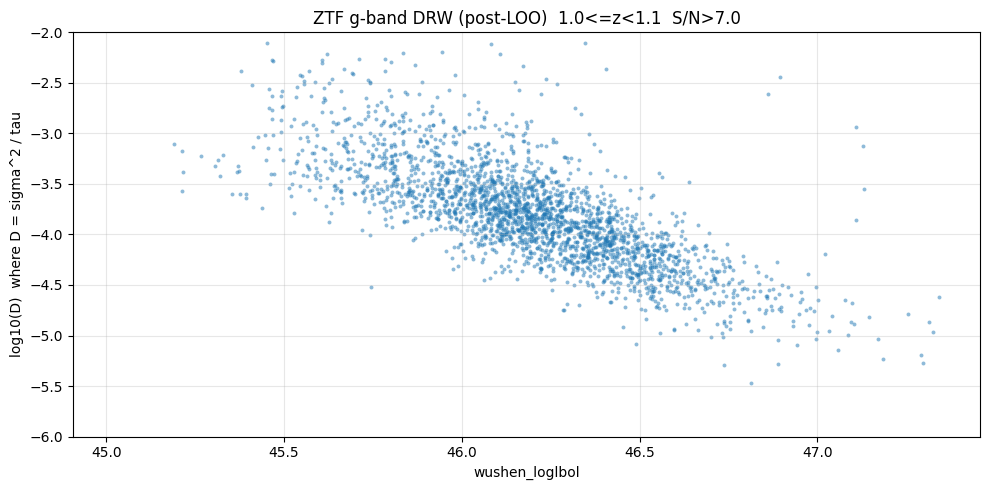

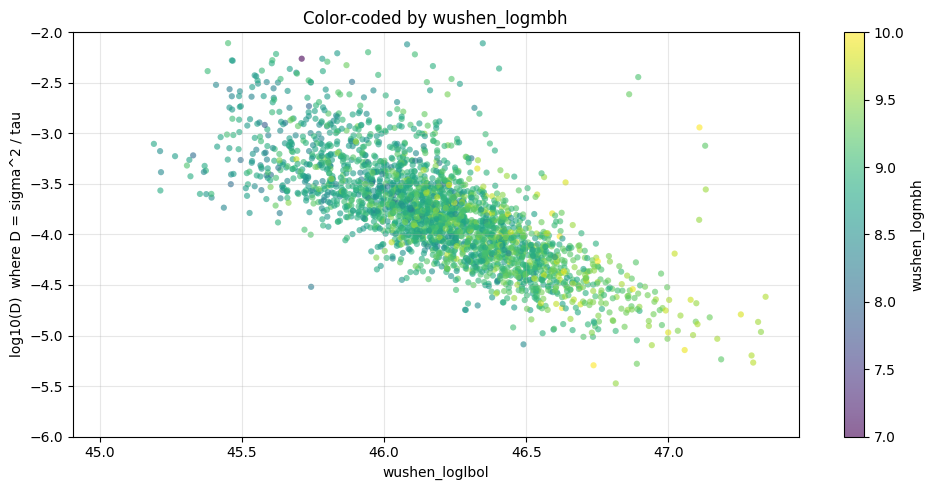

In [45]:
import matplotlib.pyplot as plt

if 'results_table' not in globals():
    print('No results_table found (did you run the LOO cell?)')
else:
    # Use log10(D) for readability (apply_loo_cleaning stores natural logD)
    log10D_post = np.array(results_table['logD_post'], dtype=float) / np.log(10.0)
    logLbol = np.array(results_table['wushen_loglbol'], dtype=float)
    logMbh = np.array(results_table['wushen_logmbh'], dtype=float)

    m = np.isfinite(log10D_post) & np.isfinite(logLbol) & np.isfinite(logMbh)
    print('Plotting points:', int(m.sum()))

    # 1) log(D) vs logLbol
    plt.figure(figsize=(10, 5))
    plt.scatter(logLbol[m], log10D_post[m], s=8, alpha=0.5, linewidths=0)
    plt.xlabel('wushen_loglbol')
    plt.ylabel('log10(D)  where D = sigma^2 / tau')
    sn_val = SN_THRESHOLD_TUNED if SN_THRESHOLD_TUNED is not None else SN_THRESHOLD
    sn_text = f"{sn_val:.1f}" if sn_val is not None else "?"
    plt.title(f'ZTF g-band DRW (post-LOO)  {Z_MIN}<=z<{Z_MAX}  S/N>{sn_text}')
    plt.grid(alpha=0.3)
    plt.ylim(-6,-2)
    plt.tight_layout()
    plt.show()

    # 2) color-coded by log(M_BH)
    plt.figure(figsize=(10, 5))
    sc = plt.scatter(logLbol[m], log10D_post[m], c=logMbh[m], s=20, alpha=0.6, linewidths=0, cmap='viridis', vmin=7, vmax=10)
    plt.xlabel('wushen_loglbol')
    plt.ylabel('log10(D)  where D = sigma^2 / tau')
    plt.title('Color-coded by wushen_logmbh')
    plt.grid(alpha=0.3)
    plt.ylim(-6,-2)
    cb = plt.colorbar(sc)
    cb.set_label('wushen_logmbh')
    plt.tight_layout()
    plt.show()


N used: 2516

Robust (Theil–Sen) fit: y = a + b*x
  a = 52.48660
  b = -1.21883  (95% CI [-1.26014, -1.17798])
  residual std = 0.37569


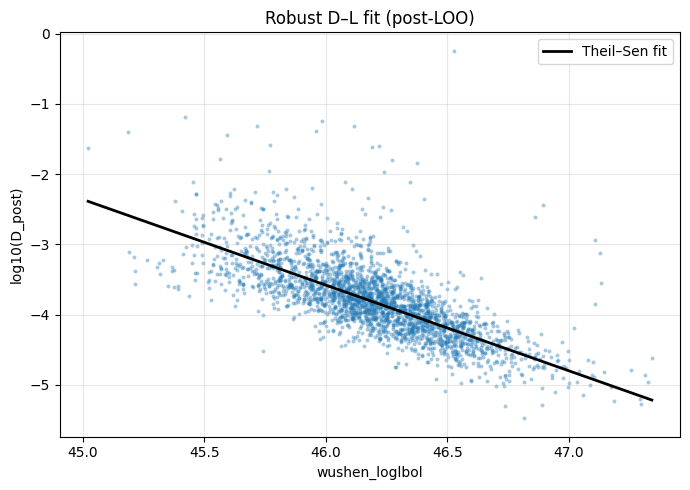

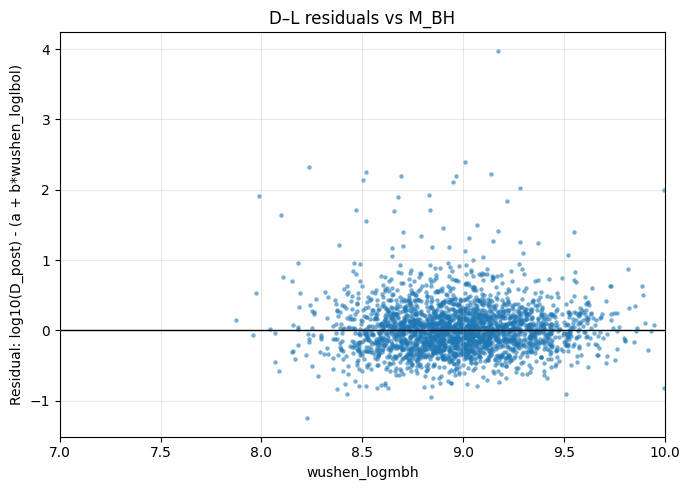

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)



Residual ~ M_BH correlations:
  Pearson r = -0.0123, p = 5.390e-01
  Spearman ρ = 0.0387, p = 5.246e-02

Partial test (control for Lbol by residualizing M_BH on Lbol):
  Pearson r(res, M_BH|Lbol) = -0.0180, p = 3.668e-01
  Spearman ρ(res, M_BH|Lbol) = 0.0330, p = 9.811e-02

OLS: y = a + b*Lbol + c*M_BH
  a = 51.71747  (p=0.000e+00)
  b = -1.19761  (p=0.000e+00)
  c = -0.02034  (p=3.668e-01)   <-- M_BH term
  R^2 = 0.5148


/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/4158624107.py:86: RuntimeWarning: divide by zero encountered in matmul
  y_ols = X @ beta
/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/4158624107.py:86: RuntimeWarning: overflow encountered in matmul
  y_ols = X @ beta
/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/4158624107.py:86: RuntimeWarning: invalid value encountered in matmul
  y_ols = X @ beta
/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/4158624107.py:89: RuntimeWarning: divide by zero encountered in matmul
  s2 = (e @ e) / dof
/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/4158624107.py:89: RuntimeWarning: overflow encountered in matmul
  s2 = (e @ e) / dof
/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/4158624107.py:89: RuntimeWarning: invalid value encountered in matmul
  s2 = (e @ e) / dof


In [46]:
# Robust D–L fit + residuals vs M_BH + correlation tests
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

assert "results_table" in globals(), "Run the LOO cell first to create results_table."

# Use log10(D) (apply_loo_cleaning stores ln(D))
y = np.array(results_table["logD_post"], dtype=float) / np.log(10.0)   # log10(D_post)
x = np.array(results_table["wushen_loglbol"], dtype=float)             # log10(Lbol)
m = np.array(results_table["wushen_logmbh"], dtype=float)              # log10(M_BH)

mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(m)
x, y, m = x[mask], y[mask], m[mask]
n = len(x)
print("N used:", n)

# --------------------------
# 1) Robust regression y ~ a + b x  (Theil–Sen)
# --------------------------
slope, intercept, slope_lo, slope_hi = stats.theilslopes(y, x, 0.95)
yhat = intercept + slope * x
res = y - yhat

print("\nRobust (Theil–Sen) fit: y = a + b*x")
print(f"  a = {intercept:.5f}")
print(f"  b = {slope:.5f}  (95% CI [{slope_lo:.5f}, {slope_hi:.5f}])")
print(f"  residual std = {np.std(res):.5f}")

# Quick diagnostic plot: D–L with robust line
xs = np.linspace(np.min(x), np.max(x), 200)
plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=8, alpha=0.4, linewidths=0)
plt.plot(xs, intercept + slope * xs, color="k", lw=2, label="Theil–Sen fit")
plt.xlabel("wushen_loglbol")
plt.ylabel("log10(D_post)")
plt.title("Robust D–L fit (post-LOO)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------
# 2) Plot residuals vs M_BH
# --------------------------
plt.figure(figsize=(7, 5))
plt.scatter(m, res, s=10, alpha=0.6, linewidths=0)
plt.axhline(0.0, color="k", lw=1)
plt.xlim(7,10)
plt.xlabel("wushen_logmbh")
plt.ylabel("Residual: log10(D_post) - (a + b*wushen_loglbol)")
plt.title("D–L residuals vs M_BH")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------
# 3) Tests: correlation of residuals with M_BH
# --------------------------
pear_r, pear_p = stats.pearsonr(res, m)
spear_rho, spear_p = stats.spearmanr(res, m)

print("\nResidual ~ M_BH correlations:")
print(f"  Pearson r = {pear_r:.4f}, p = {pear_p:.3e}")
print(f"  Spearman ρ = {spear_rho:.4f}, p = {spear_p:.3e}")

# --------------------------
# 4) Partial test controlling for Lbol:
#    correlate residuals with (M_BH residualized on Lbol)
# --------------------------
mbh_slope, mbh_intercept = np.polyfit(x, m, 1)
m_res = m - (mbh_intercept + mbh_slope * x)

pear_r_pc, pear_p_pc = stats.pearsonr(res, m_res)
spear_rho_pc, spear_p_pc = stats.spearmanr(res, m_res)

print("\nPartial test (control for Lbol by residualizing M_BH on Lbol):")
print(f"  Pearson r(res, M_BH|Lbol) = {pear_r_pc:.4f}, p = {pear_p_pc:.3e}")
print(f"  Spearman ρ(res, M_BH|Lbol) = {spear_rho_pc:.4f}, p = {spear_p_pc:.3e}")

# --------------------------
# 5) Optional: OLS multiple regression y ~ 1 + x + m (report coefficient on M_BH)
# --------------------------
X = np.column_stack([np.ones(n), x, m])
beta, *_ = np.linalg.lstsq(X, y, rcond=None)
y_ols = X @ beta
e = y - y_ols
dof = n - X.shape[1]
s2 = (e @ e) / dof
cov = s2 * np.linalg.inv(X.T @ X)
se = np.sqrt(np.diag(cov))
tstat = beta / se
pvals = 2 * stats.t.sf(np.abs(tstat), dof)

ss_tot = np.sum((y - np.mean(y)) ** 2)
ss_res = np.sum(e ** 2)
r2 = 1.0 - ss_res / ss_tot

print("\nOLS: y = a + b*Lbol + c*M_BH")
print(f"  a = {beta[0]:.5f}  (p={pvals[0]:.3e})")
print(f"  b = {beta[1]:.5f}  (p={pvals[1]:.3e})")
print(f"  c = {beta[2]:.5f}  (p={pvals[2]:.3e})   <-- M_BH term")
print(f"  R^2 = {r2:.4f}")

N used: 2516


/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/4098354831.py:38: RuntimeWarning: divide by zero encountered in matmul
  r = y - X @ beta
/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/4098354831.py:38: RuntimeWarning: overflow encountered in matmul
  r = y - X @ beta
/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/4098354831.py:38: RuntimeWarning: invalid value encountered in matmul
  r = y - X @ beta
/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/4098354831.py:75: RuntimeWarning: divide by zero encountered in matmul
  r = y - X @ beta
/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/4098354831.py:75: RuntimeWarning: overflow encountered in matmul
  r = y - X @ beta
/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/4098354831.py:75: RuntimeWarning: invalid value encountered in matmul
  r = y - X @ beta



IRLS robust fit (huber): y = a + b*(x-median(x))
  a = -3.818560
  b = -1.204240
  robust scale (MAD) s = 0.295961
  downweighted fraction (w<0.5): 0.034


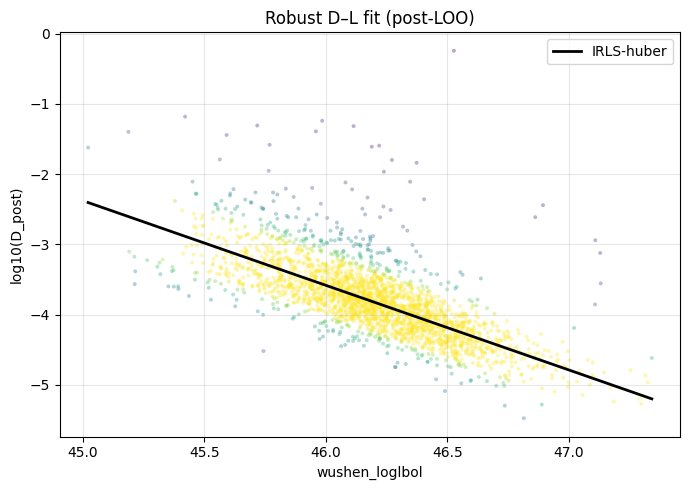

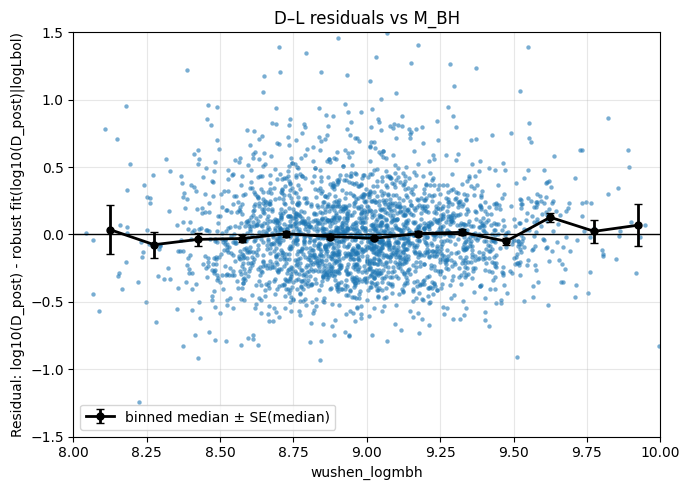

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)



Residual ~ M_BH correlations:
  Pearson r = -0.0175, p = 3.816e-01
  Spearman ρ = 0.0327, p = 1.013e-01

Partial test (control for Lbol by residualizing M_BH on Lbol):
  Pearson r(res, M_BH|Lbol) = -0.0180, p = 3.668e-01
  Spearman ρ(res, M_BH|Lbol) = 0.0336, p = 9.167e-02


In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

assert "results_table" in globals(), "Run the LOO cell first to create results_table."

# --------------------------
# Data
# --------------------------
y = np.array(results_table["logD_post"], dtype=float) / np.log(10.0)   # log10(D_post); logD_post is ln(D)
x = np.array(results_table["wushen_loglbol"], dtype=float)             # log10(Lbol)
m = np.array(results_table["wushen_logmbh"], dtype=float)              # log10(M_BH)

mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(m)
x, y, m = x[mask], y[mask], m[mask]
n = len(x)
print("N used:", n)

# Centering improves conditioning + avoids numerical warnings later
x0 = x - np.median(x)

# --------------------------
# Robust linear fit via IRLS (Huber or Tukey)
# --------------------------
def irls_robust_line(x, y, loss="huber", c=1.345, max_iter=100, tol=1e-8):
    """
    Robust fit y ~ a + b*x using IRLS.
    loss: 'huber' or 'tukey'
    c: tuning constant (Huber default ~1.345 for ~95% efficiency at Gaussian)
    Returns: a, b, weights, robust_scale
    """
    X = np.column_stack([np.ones_like(x), x])

    # Start from OLS
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)

    for _ in range(max_iter):
        r = y - X @ beta

        # robust scale via MAD
        mad = np.median(res := np.abs(r - np.median(r)))
        s = 1.4826 * mad if mad > 0 else np.std(r)
        if not np.isfinite(s) or s <= 0:
            s = np.std(r) if np.std(r) > 0 else 1.0

        u = r / s

        if loss.lower() == "huber":
            w = np.ones_like(u)
            au = np.abs(u)
            mask_big = au > c
            w[mask_big] = c / au[mask_big]
        elif loss.lower() == "tukey":
            # Tukey biweight: harder rejection of outliers
            w = np.zeros_like(u)
            au = np.abs(u)
            mask_in = au < c
            t = u[mask_in] / c
            w[mask_in] = (1 - t**2) ** 2
        else:
            raise ValueError("loss must be 'huber' or 'tukey'")

        # Weighted least squares update
        W = np.sqrt(w)
        Xw = X * W[:, None]
        yw = y * W
        beta_new, *_ = np.linalg.lstsq(Xw, yw, rcond=None)

        if np.max(np.abs(beta_new - beta)) < tol:
            beta = beta_new
            break
        beta = beta_new

    # final scale
    r = y - X @ beta
    mad = np.median(np.abs(r - np.median(r)))
    s = 1.4826 * mad if mad > 0 else np.std(r)
    return beta[0], beta[1], w, s

# Choose loss: 'huber' (usually a good default) or 'tukey' (more aggressive)
LOSS = "huber"
a, b, w, s = irls_robust_line(x0, y, loss=LOSS, c=1.345)

yhat = a + b * x0
res = y - yhat

print(f"\nIRLS robust fit ({LOSS}): y = a + b*(x-median(x))")
print(f"  a = {a:.6f}")
print(f"  b = {b:.6f}")
print(f"  robust scale (MAD) s = {s:.6f}")
print(f"  downweighted fraction (w<0.5): {(w < 0.5).mean():.3f}")

# Plot fit
xs = np.linspace(np.min(x0), np.max(x0), 200)
plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=8, alpha=0.35, linewidths=0, c=w, cmap="viridis")
plt.plot(xs + np.median(x), a + b*xs, color="k", lw=2, label=f"IRLS-{LOSS}")
plt.xlabel("wushen_loglbol")
plt.ylabel("log10(D_post)")
plt.title("Robust D–L fit (post-LOO)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Residuals vs M_BH
plt.figure(figsize=(7, 5))
plt.scatter(m, res, s=10, alpha=0.6, linewidths=0)
plt.axhline(0.0, color="k", lw=1)
plt.xlim(7, 10)
plt.xlabel("wushen_logmbh")
plt.ylabel("Residual: log10(D_post) - robust fit(log10(D_post)|logLbol)")
plt.title("D–L residuals vs M_BH")
plt.xlim(8,10)
plt.ylim(-1.5,1.5)
plt.grid(alpha=0.3)
plt.tight_layout()

from scipy.stats import binned_statistic

# --- binned median residual vs M_BH (with error on the median) ---
NBINS = 20
mbh_min, mbh_max = 7.0, 10.0  # adjust if you want
bins = np.linspace(mbh_min, mbh_max, NBINS + 1)

mm = np.isfinite(m) & np.isfinite(res) & (m >= mbh_min) & (m <= mbh_max)
mbh = m[mm]
rr = res[mm]

# bin centers
centers = 0.5 * (bins[:-1] + bins[1:])

# median in bins
med, _, _ = binned_statistic(mbh, rr, statistic="median", bins=bins)

# error on median via MAD / sqrt(N) (robust)
counts, _, _ = binned_statistic(mbh, rr, statistic="count", bins=bins)
mad, _, _ = binned_statistic(mbh, rr, statistic=lambda v: np.median(np.abs(v - np.median(v))), bins=bins)
sigma_rob = 1.4826 * mad
err_med = 1.2533 * sigma_rob / np.sqrt(np.maximum(counts, 1))  # ~SE(median) for normal

# overlay on the existing residual-vs-MBH plot
okb = np.isfinite(med) & (counts > 10)
plt.errorbar(
centers[okb], med[okb], yerr=err_med[okb],
fmt="o-", color="k", lw=2, ms=5, capsize=3,
label="binned median ± SE(median)"
)
plt.legend()


plt.show()

# Correlation tests (same as before)
pear_r, pear_p = stats.pearsonr(res, m)
spear_rho, spear_p = stats.spearmanr(res, m)

print("\nResidual ~ M_BH correlations:")
print(f"  Pearson r = {pear_r:.4f}, p = {pear_p:.3e}")
print(f"  Spearman ρ = {spear_rho:.4f}, p = {spear_p:.3e}")

# Partial test: residualize M_BH on Lbol (use centered x0 for stability)
mbh_b, mbh_a = np.polyfit(x0, m, 1)  # m ≈ mbh_a + mbh_b*x0
m_res = m - (mbh_a + mbh_b * x0)

pear_r_pc, pear_p_pc = stats.pearsonr(res, m_res)
spear_rho_pc, spear_p_pc = stats.spearmanr(res, m_res)

print("\nPartial test (control for Lbol by residualizing M_BH on Lbol):")
print(f"  Pearson r(res, M_BH|Lbol) = {pear_r_pc:.4f}, p = {pear_p_pc:.3e}")
print(f"  Spearman ρ(res, M_BH|Lbol) = {spear_rho_pc:.4f}, p = {spear_p_pc:.3e}")

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


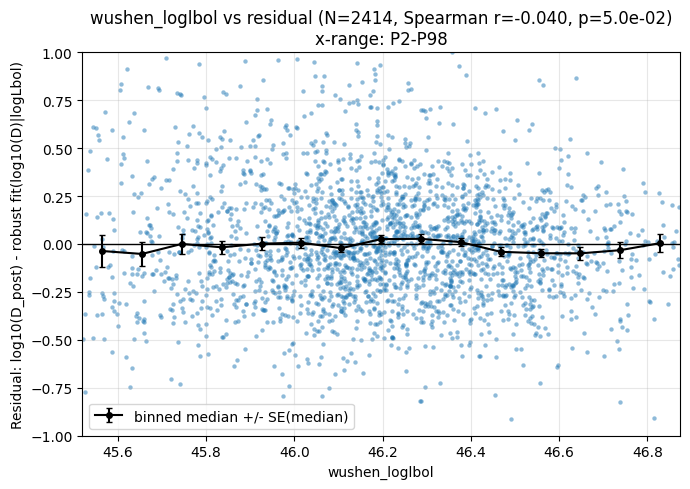

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


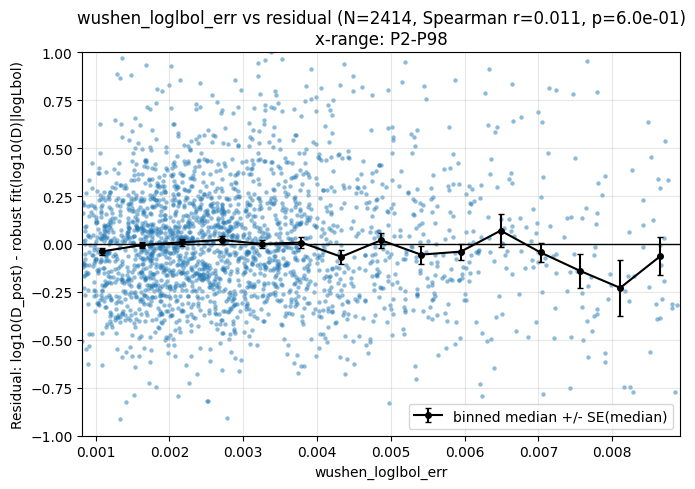

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


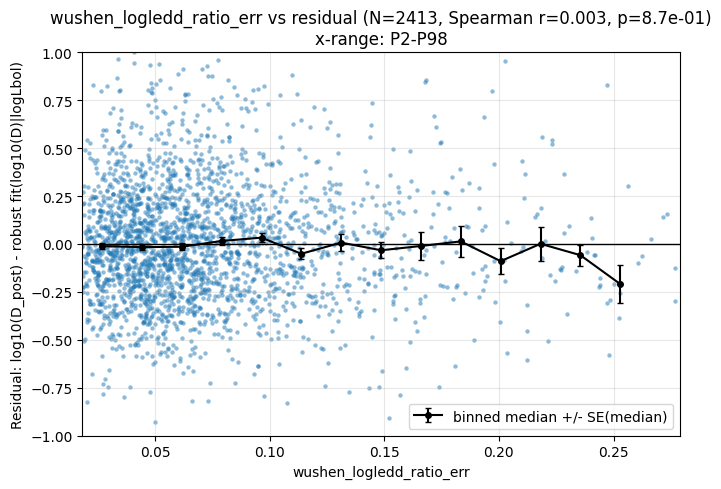

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


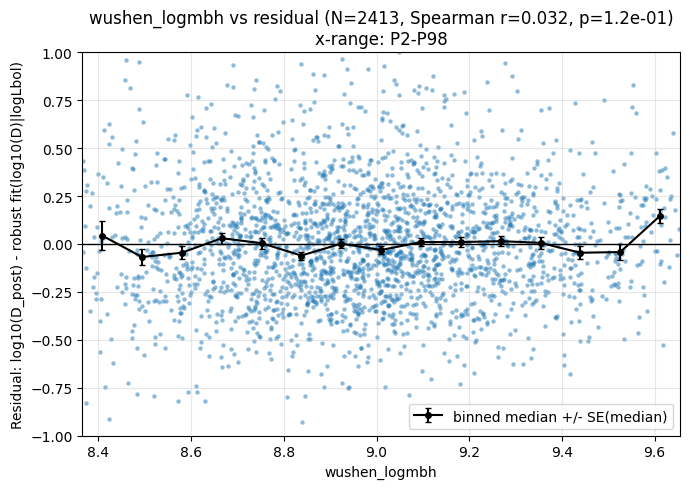

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


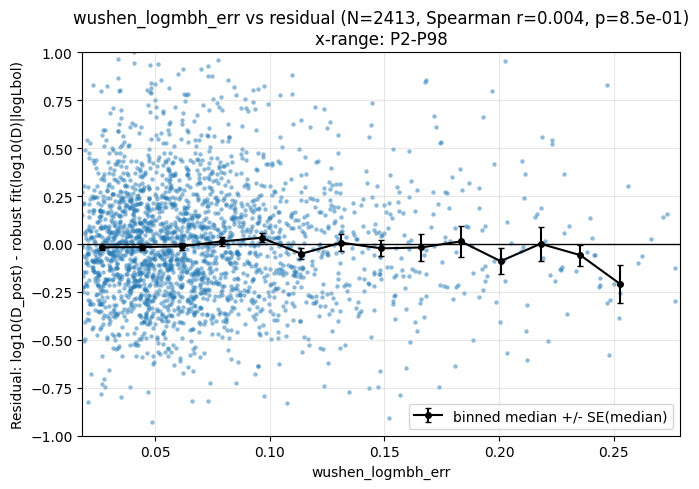

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


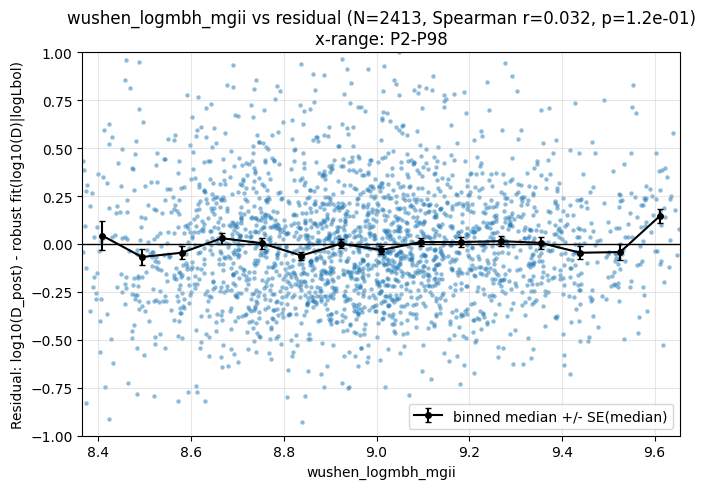

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


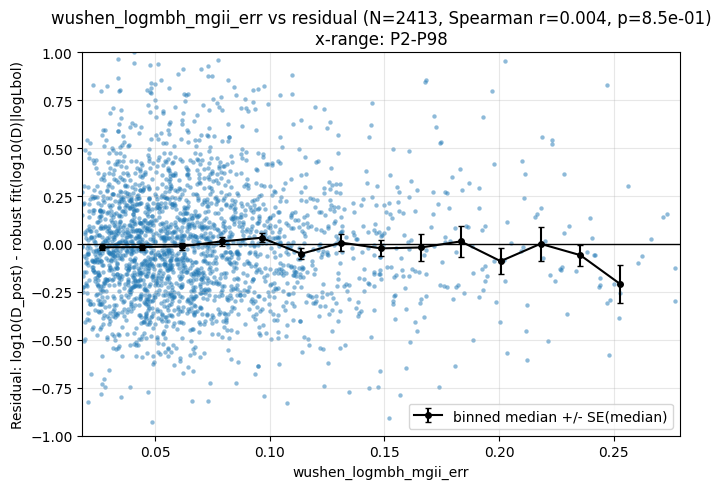

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


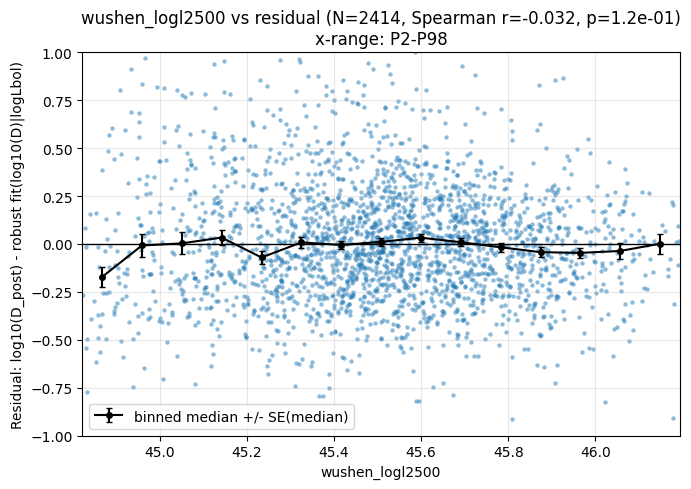

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


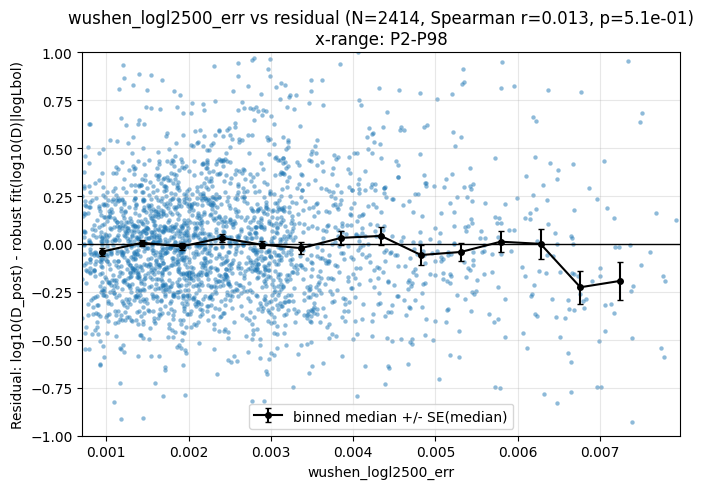

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


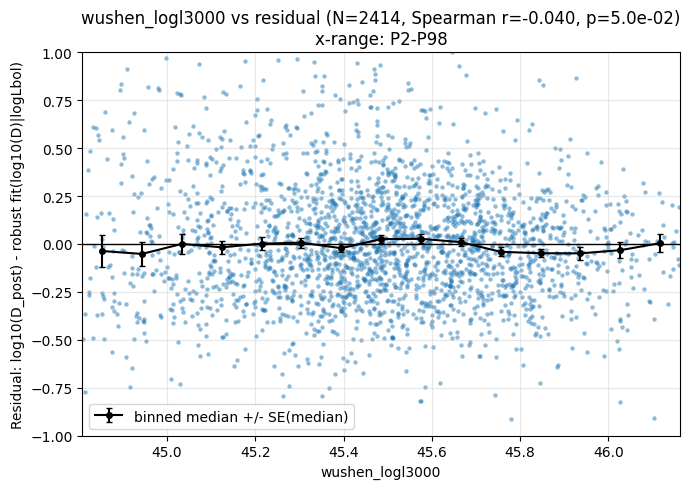

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


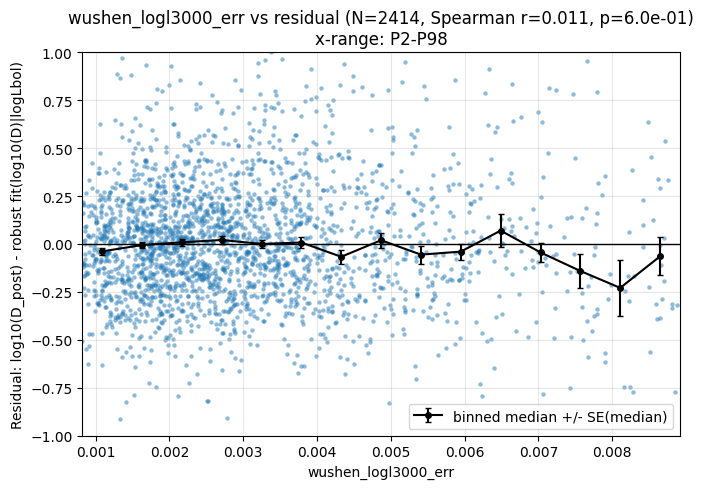

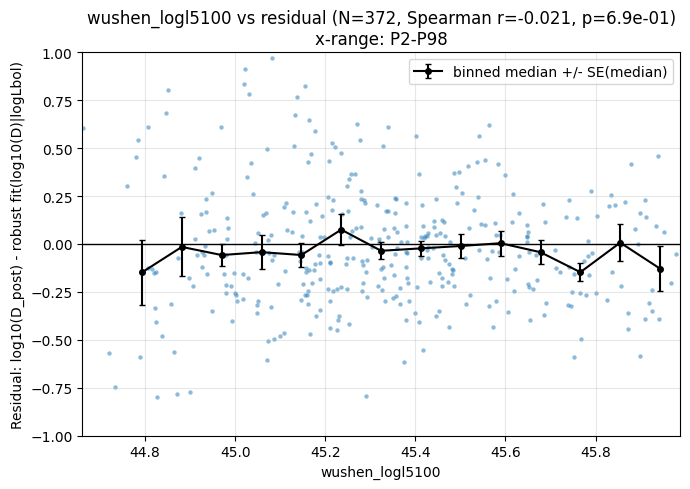

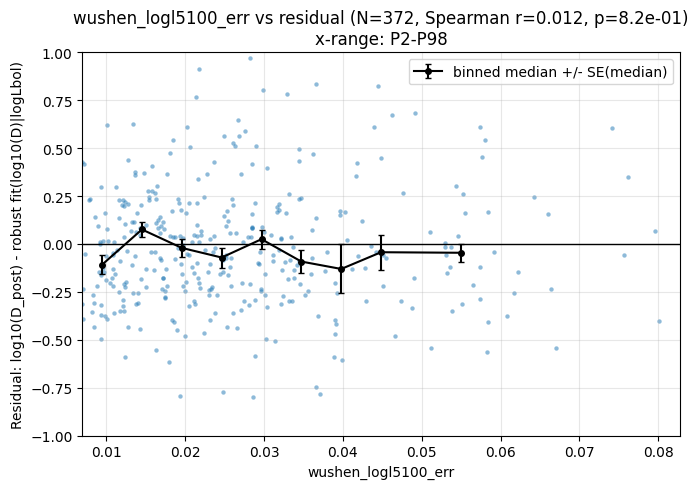

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


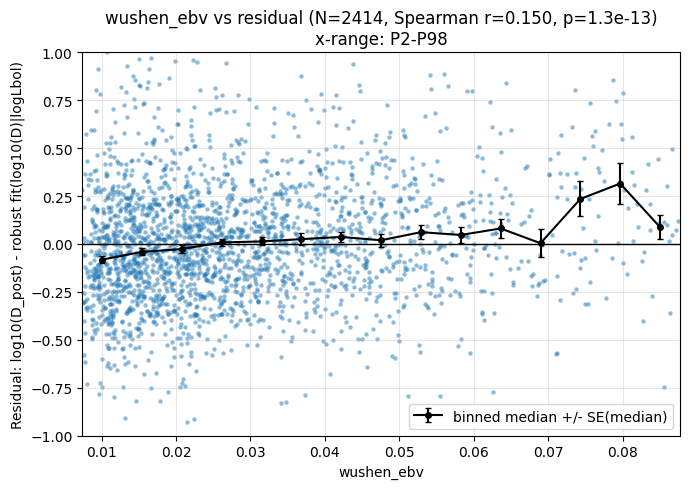

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


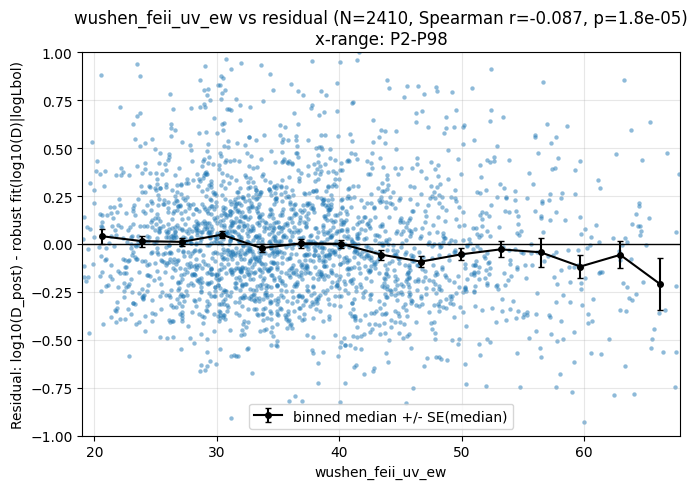

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


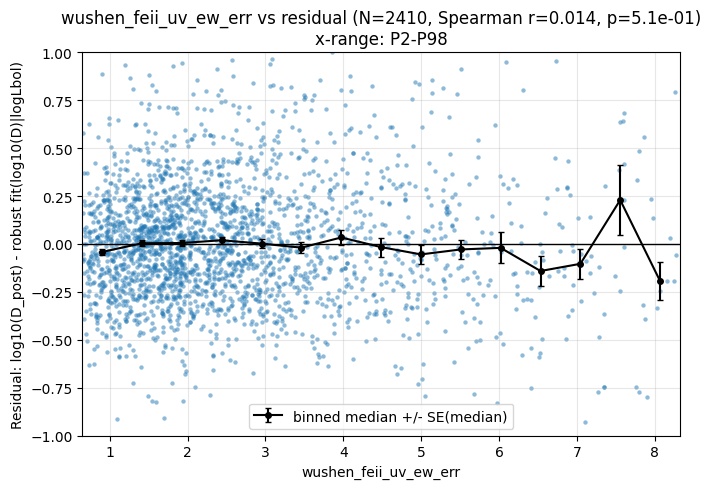

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


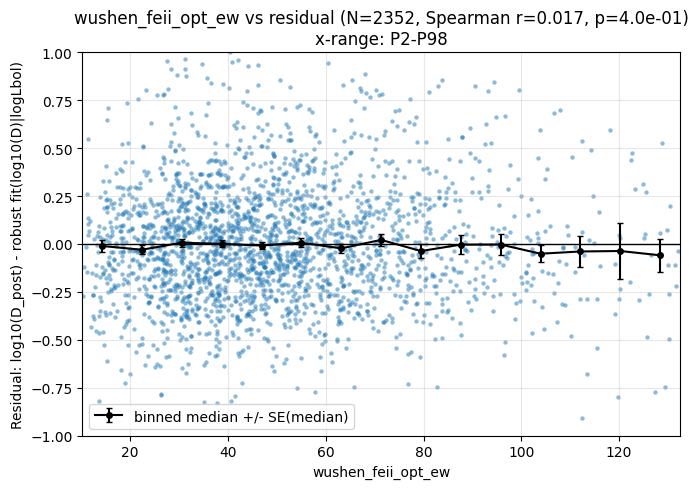

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


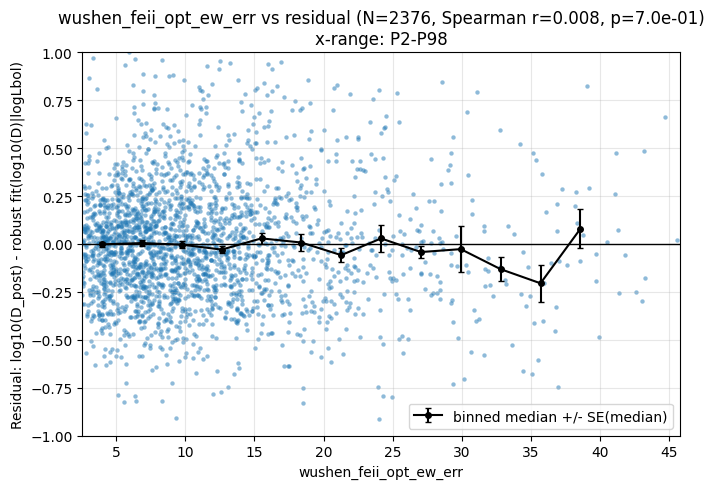

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


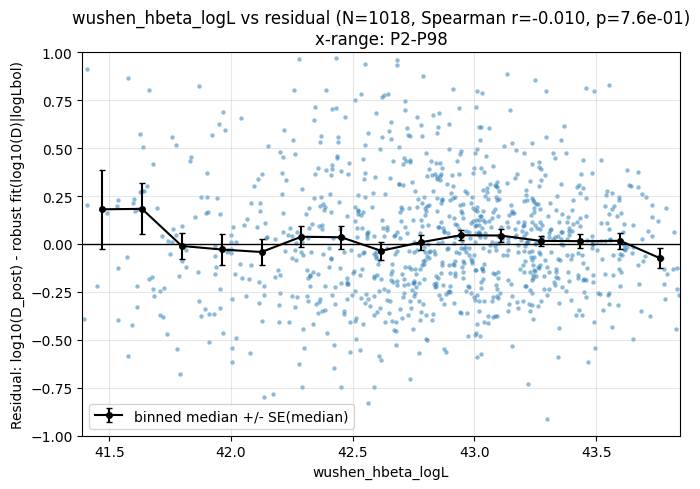

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


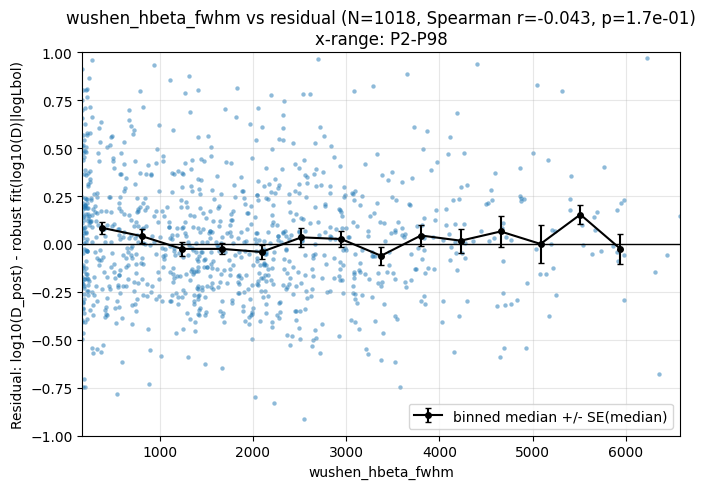

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


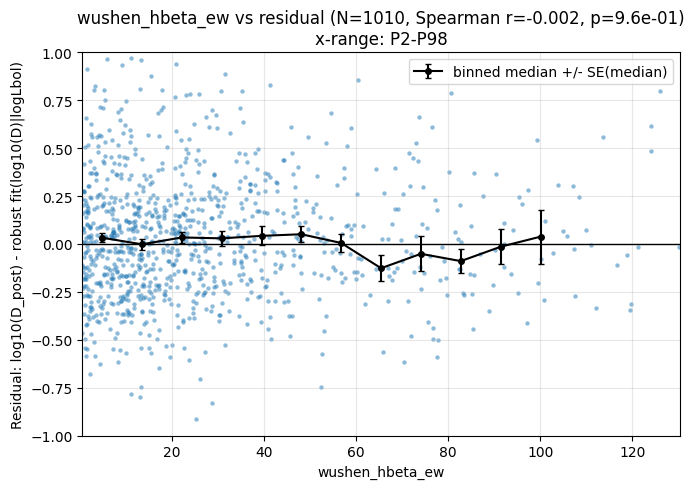

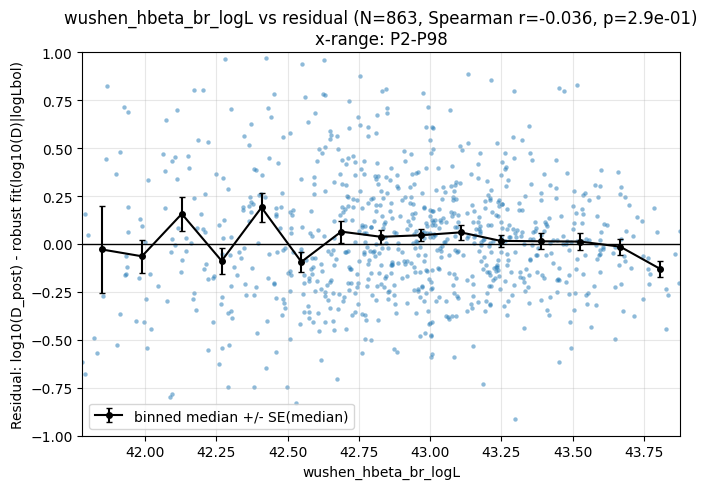

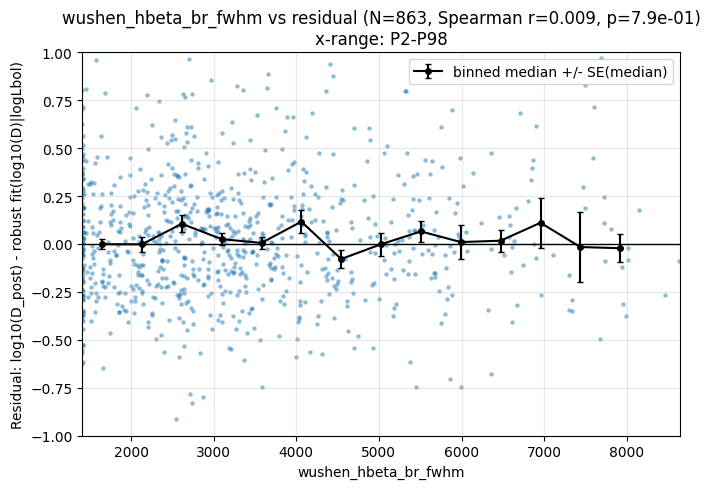

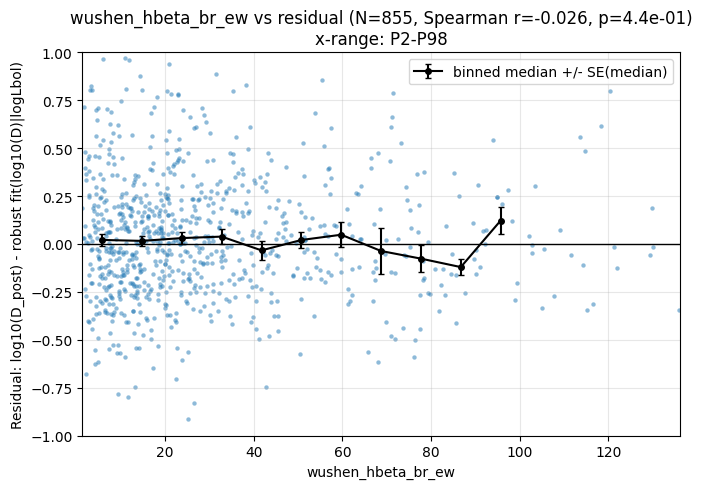

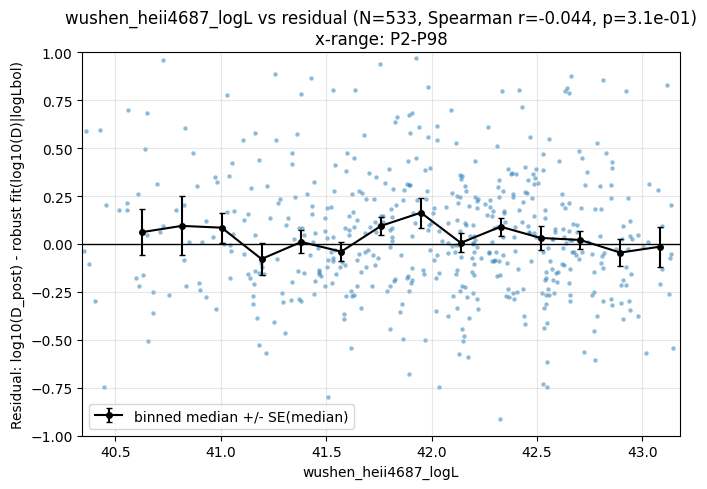

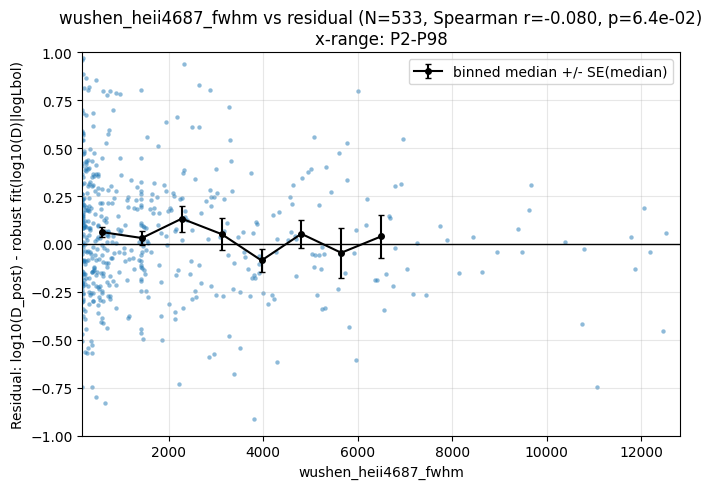

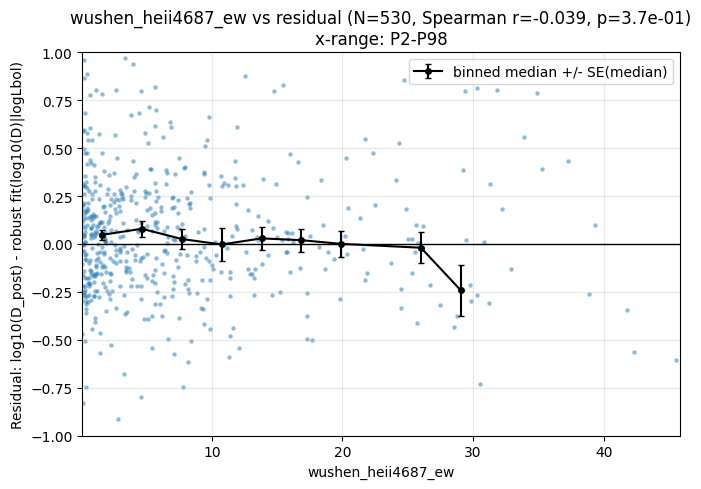

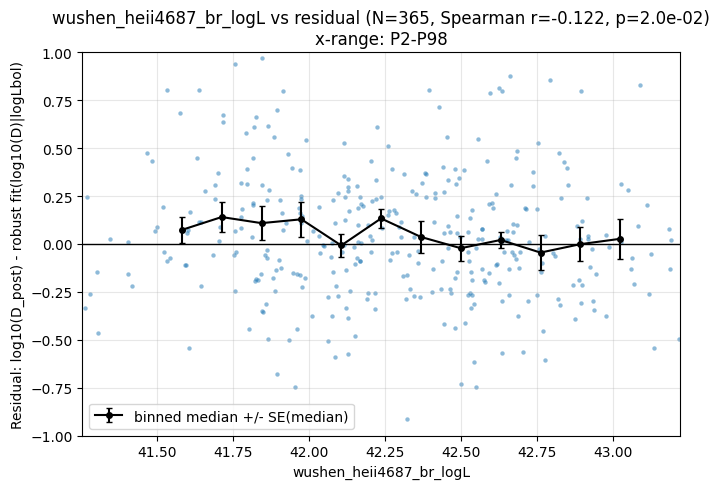

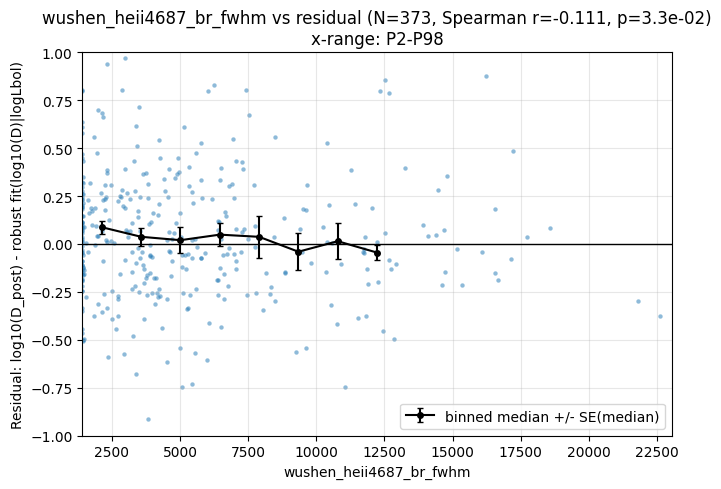

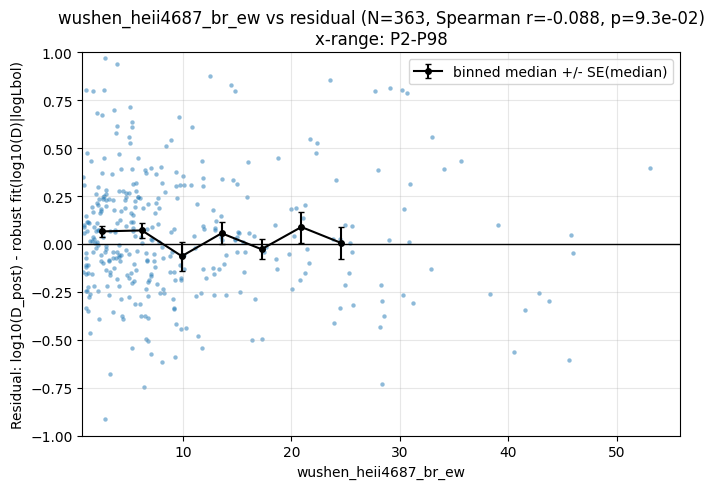

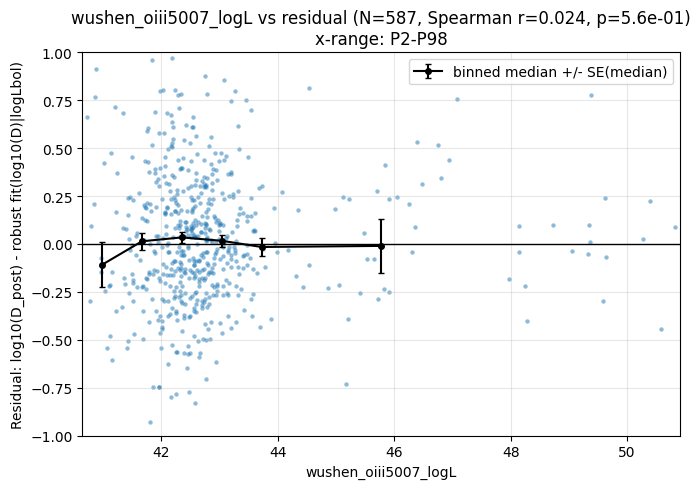

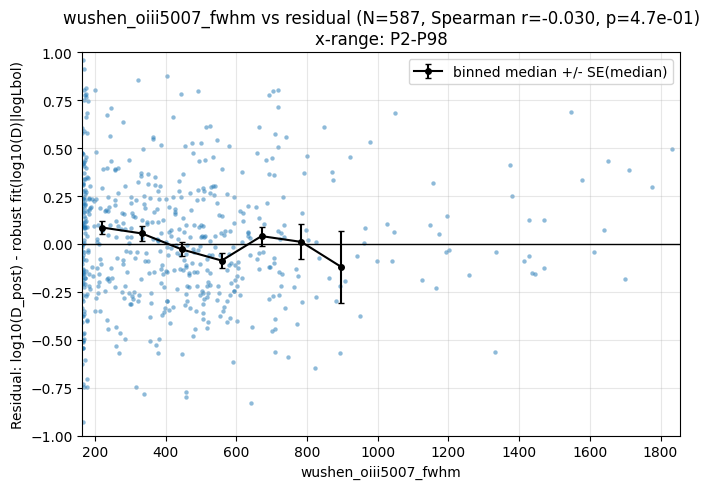

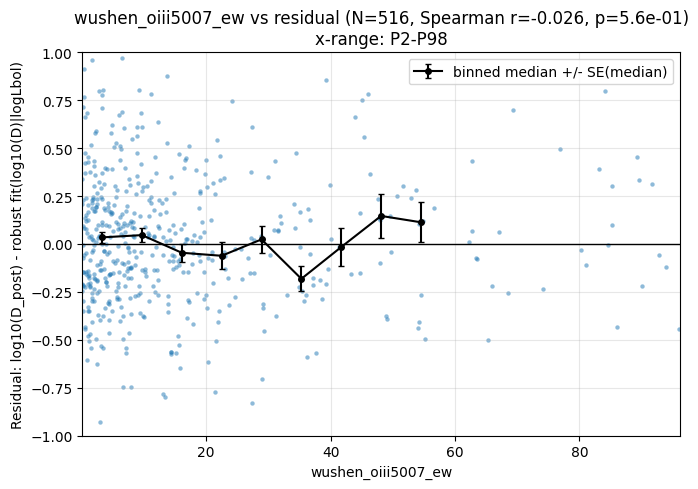

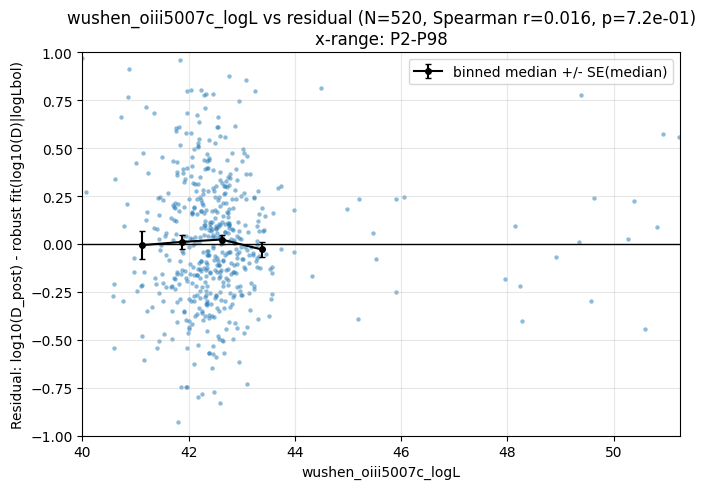

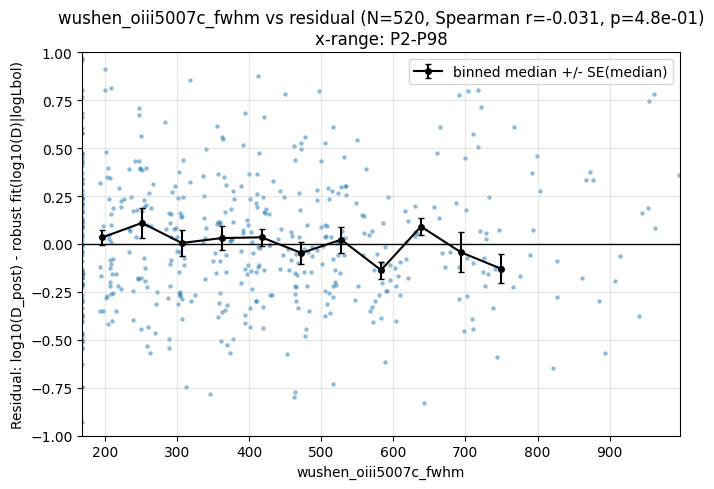

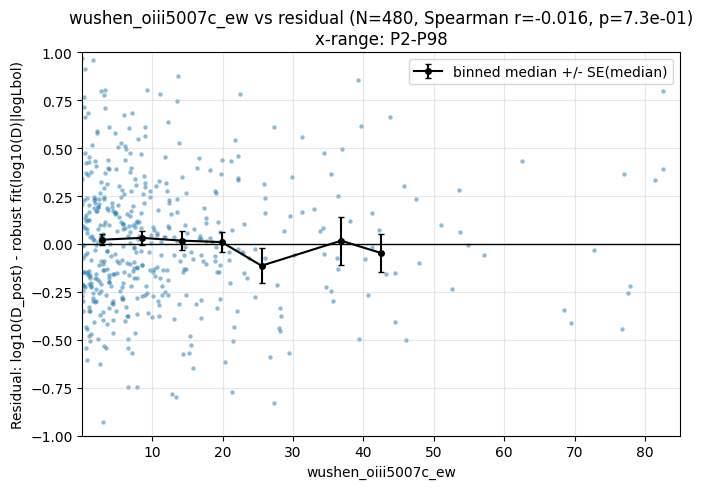

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


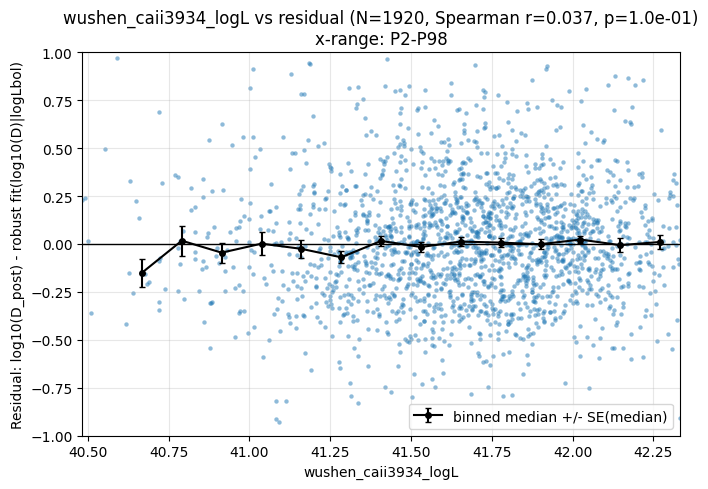

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


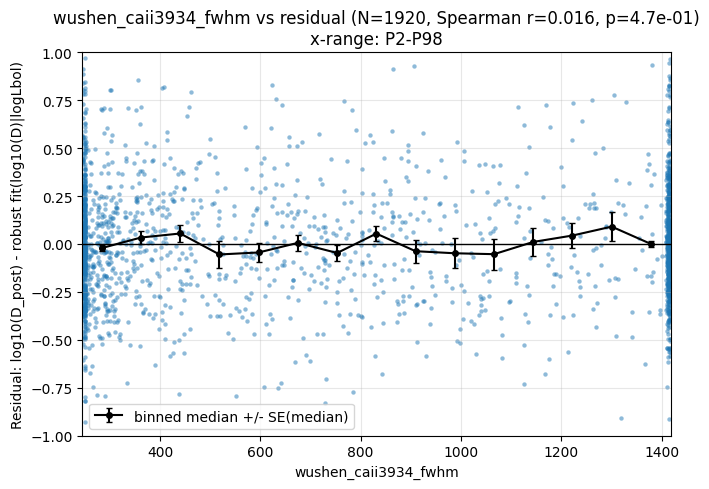

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


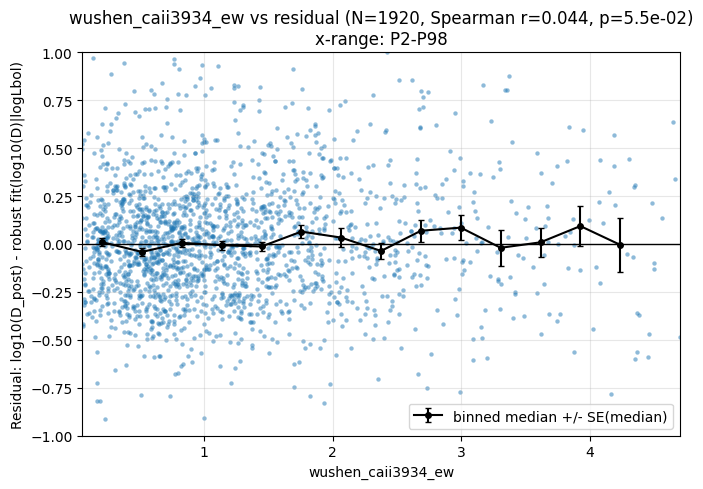

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


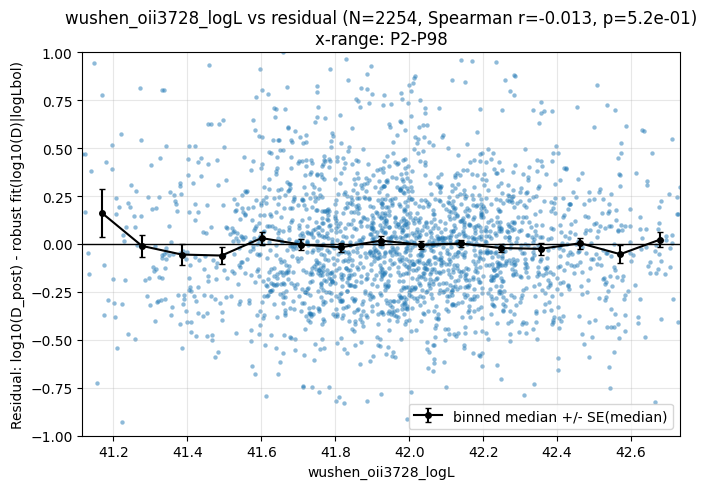

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


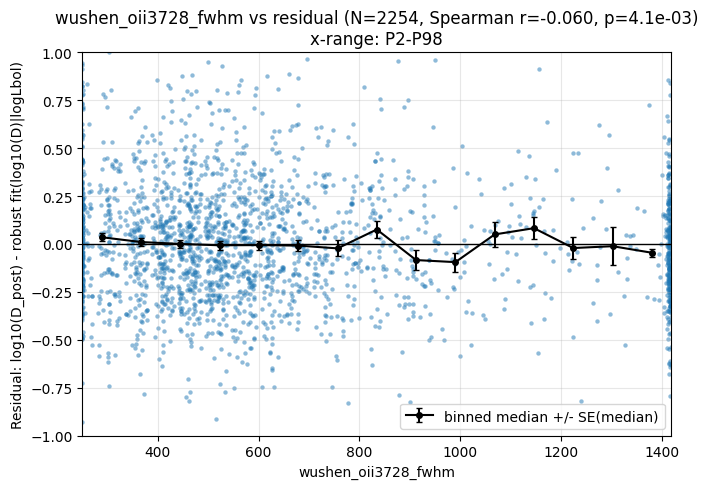

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


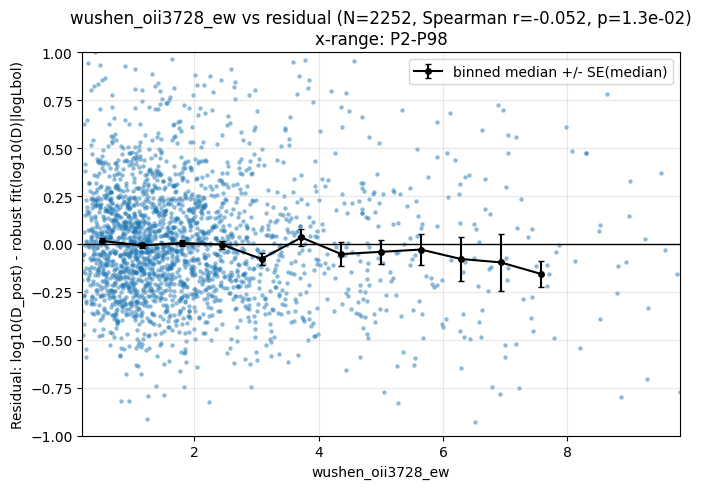

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


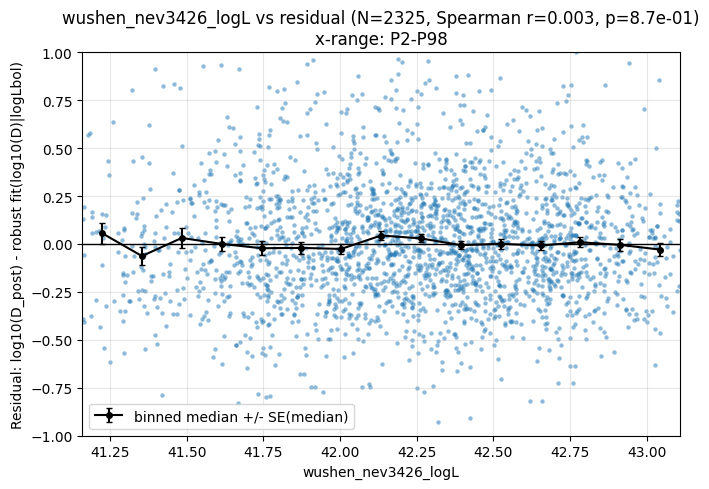

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


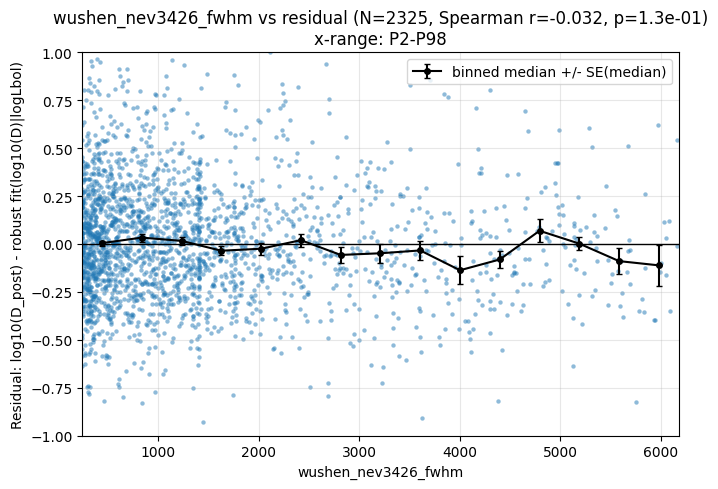

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


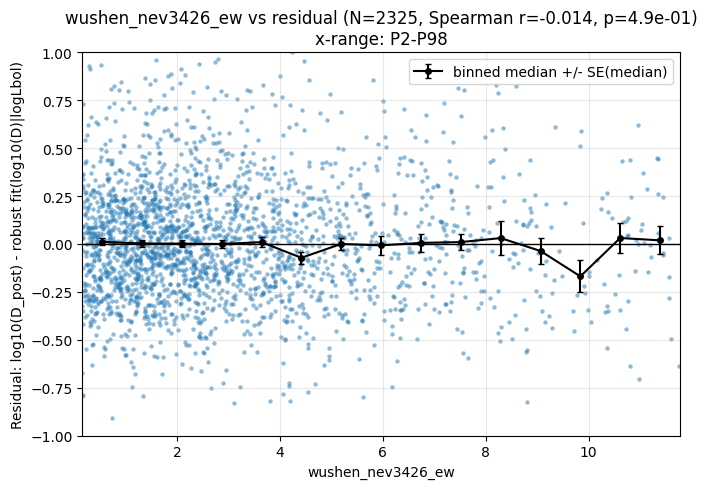

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


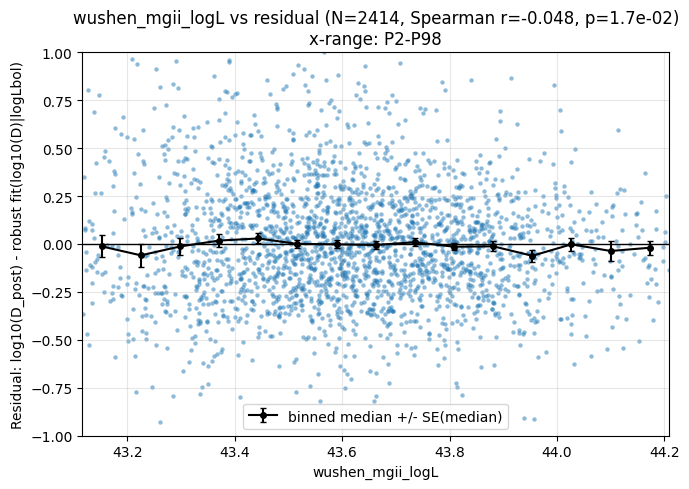

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


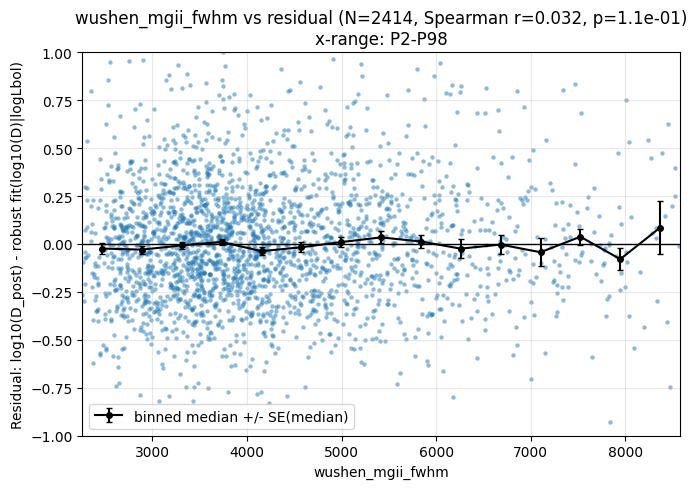

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


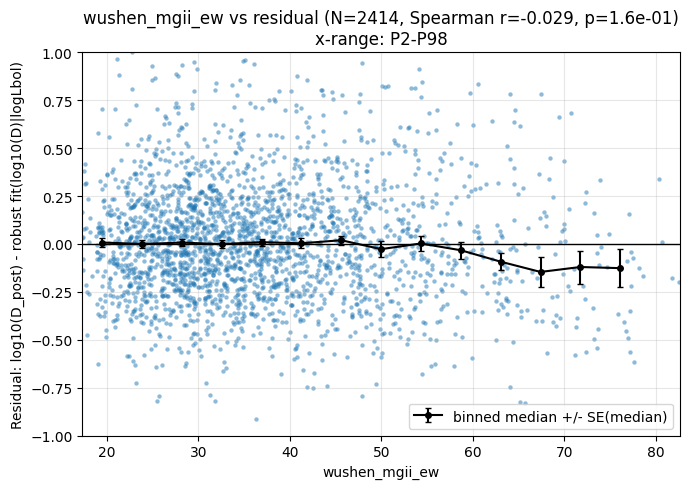

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


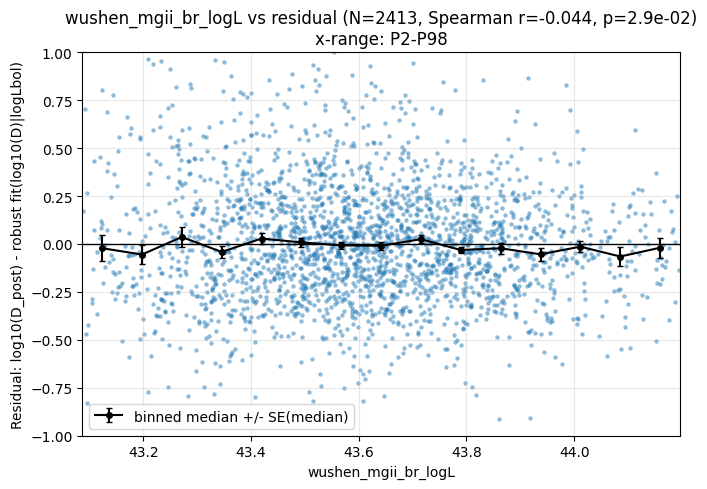

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


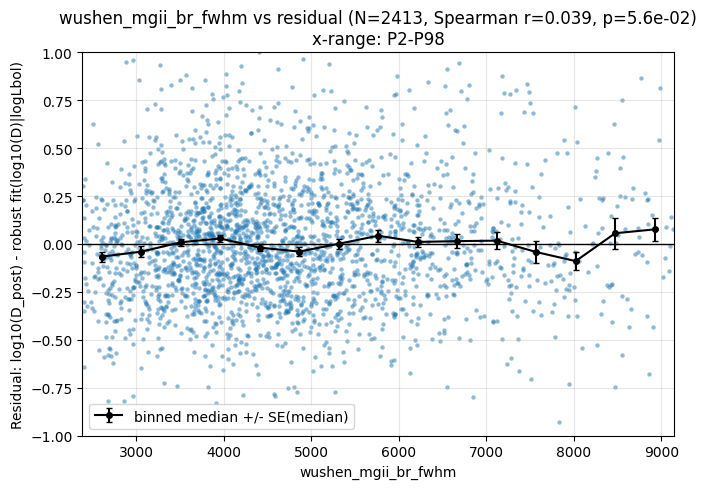

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


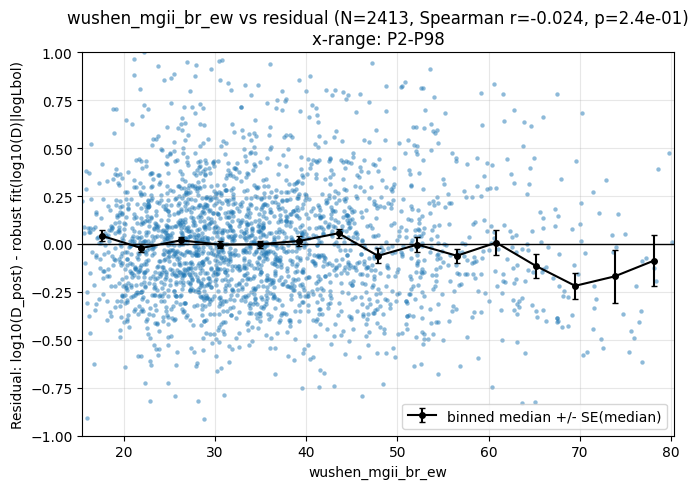

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


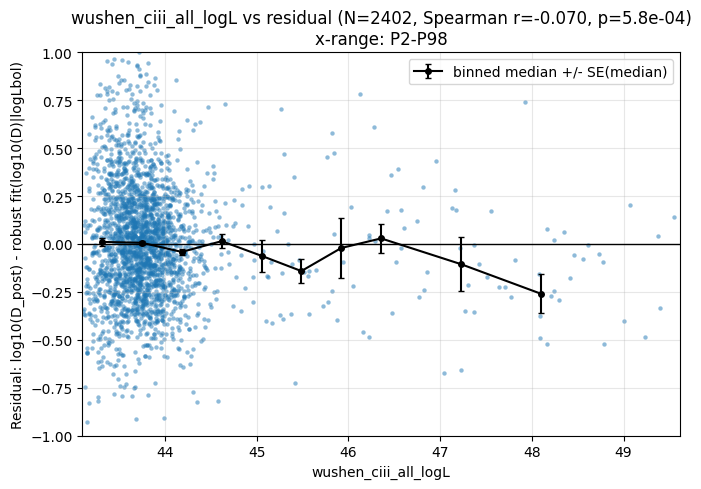

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


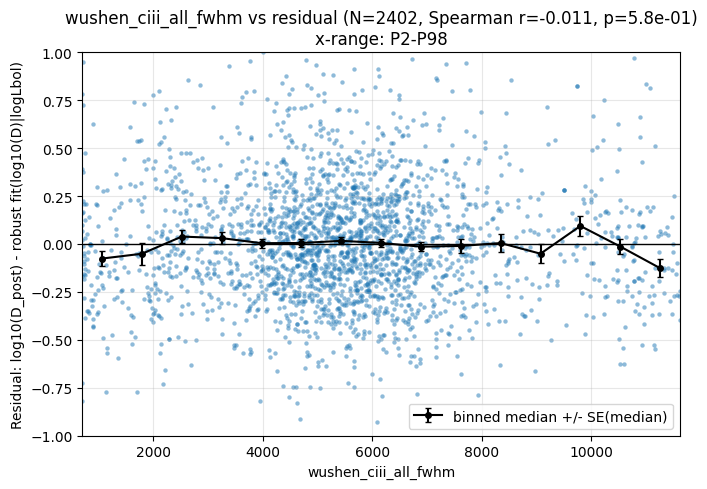

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


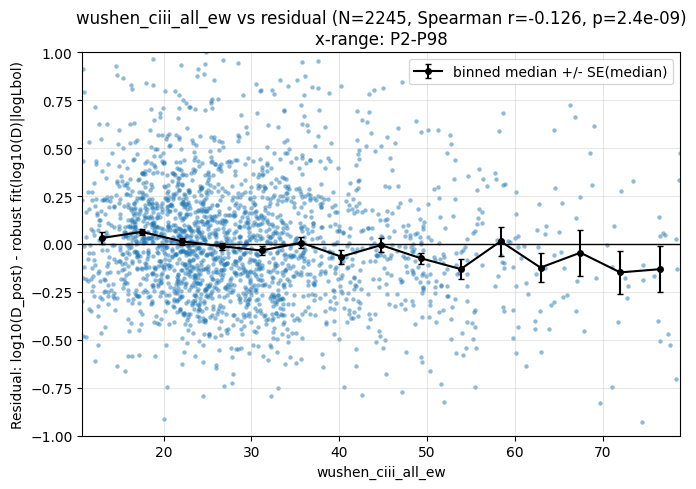

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


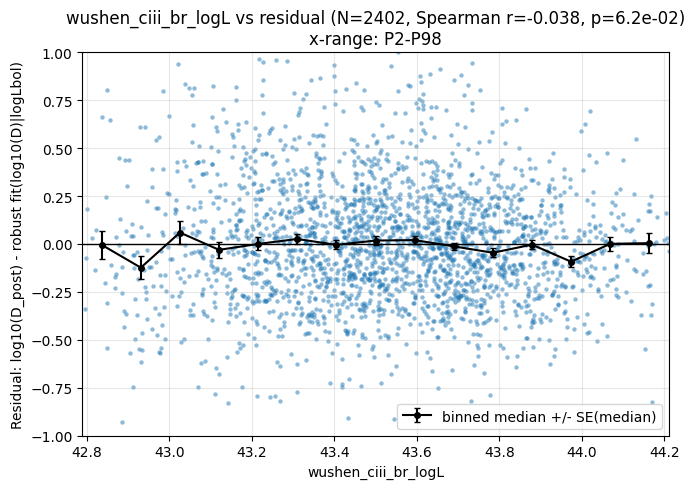

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


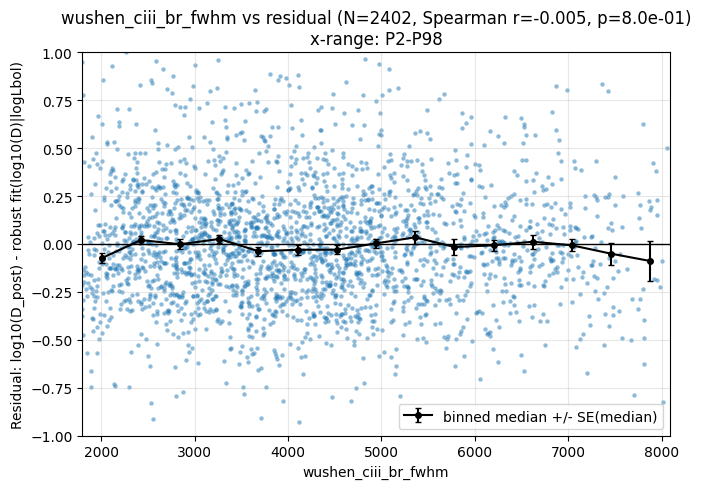

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


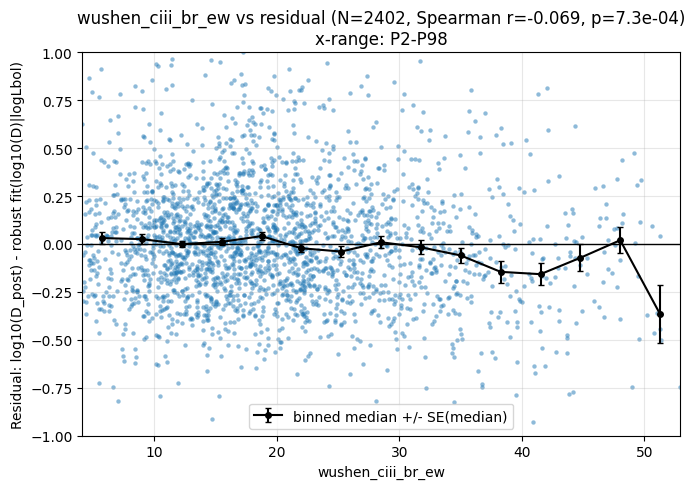

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


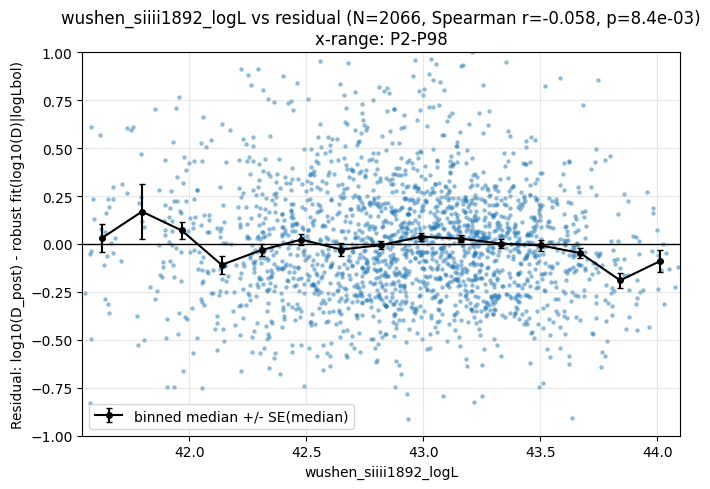

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


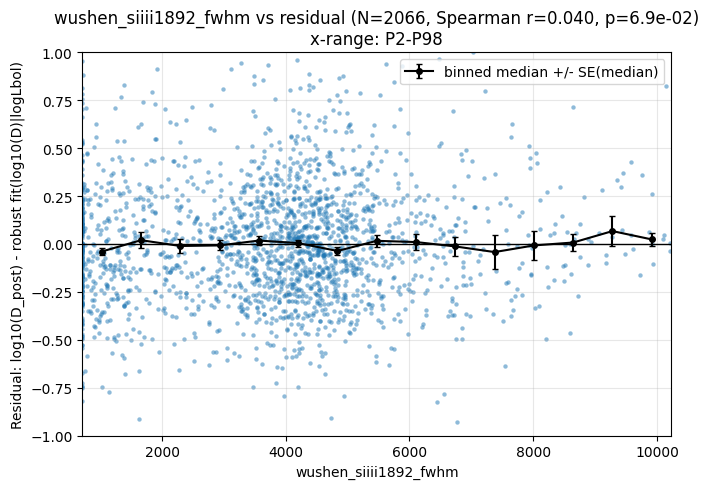

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


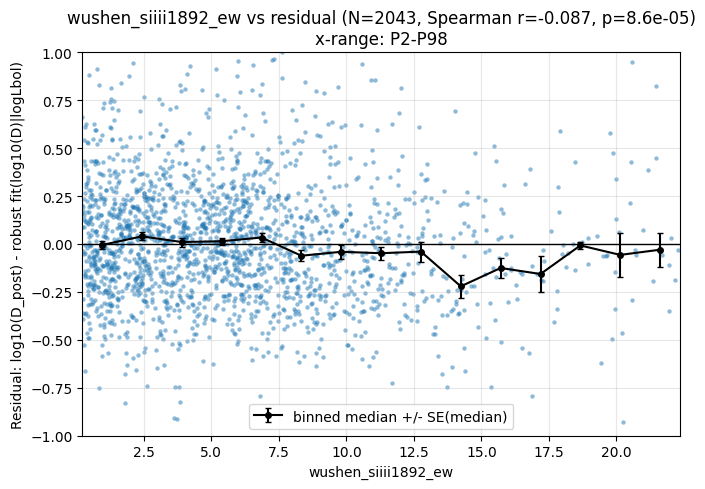

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


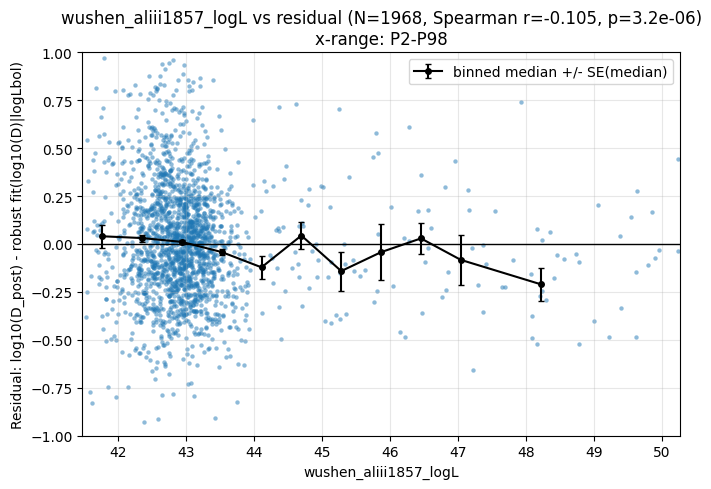

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


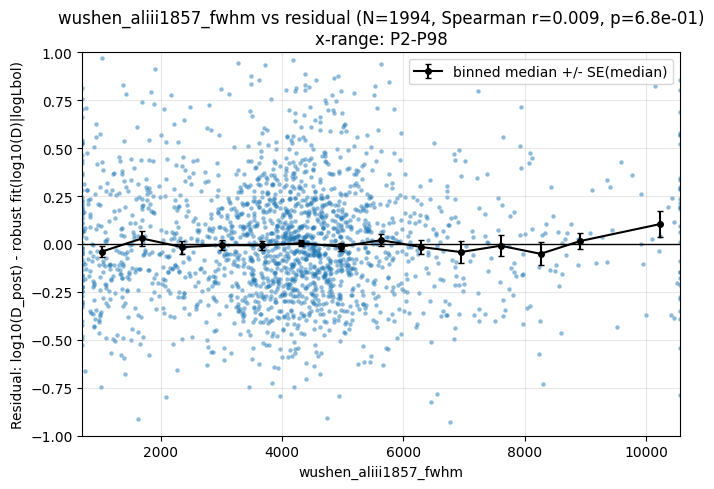

/Users/vasilybelokurov/Work/venvs/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


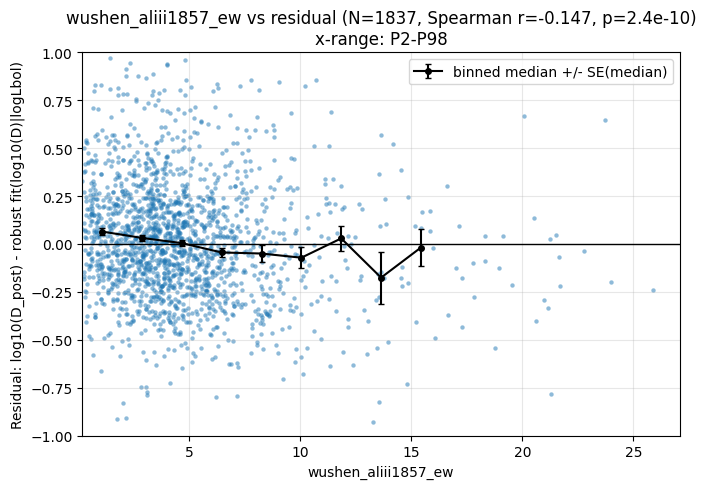

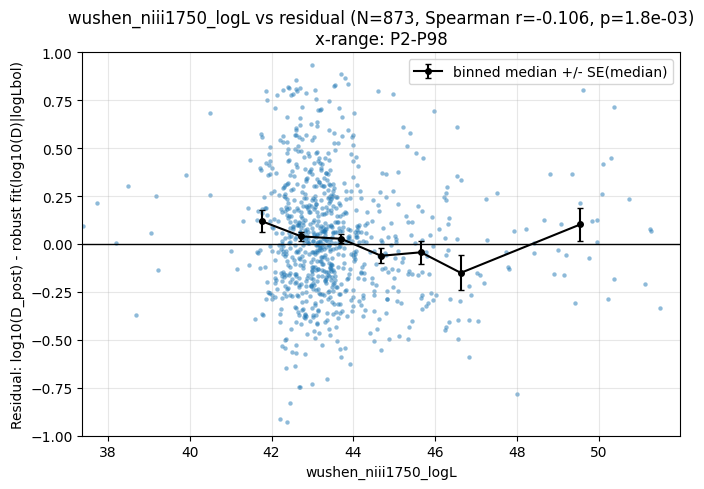

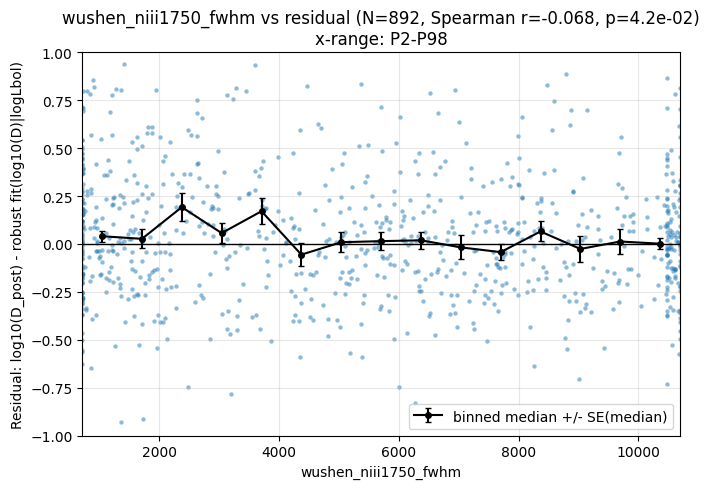

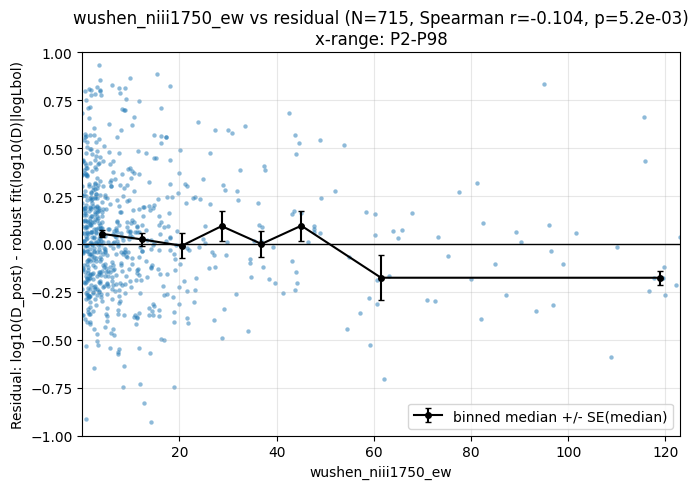


Correlation summary (sorted by |Spearman|, using P5-P95 x-range):
  driver                                             N    pearson          p   spearman          p
  wushen_ebv                                      2414     0.1201   3.21e-09     0.1499   1.34e-13
  wushen_aliii1857_ew                             1837    -0.1353   5.86e-09    -0.1471   2.39e-10
  wushen_ciii_all_ew                              2245    -0.1158   3.70e-08    -0.1255   2.40e-09
  wushen_heii4687_br_logL                          365    -0.1298   1.31e-02    -0.1219   1.98e-02
  wushen_heii4687_br_fwhm                          373    -0.1176   2.31e-02    -0.1107   3.26e-02
  wushen_niii1750_logL                             873    -0.0686   4.27e-02    -0.1057   1.77e-03
  wushen_aliii1857_logL                           1968    -0.0910   5.25e-05    -0.1047   3.23e-06
  wushen_niii1750_ew                               715    -0.0966   9.79e-03    -0.1043   5.24e-03
  wushen_heii4687_br_ew                   

In [54]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy import stats
from scipy.stats import binned_statistic

assert "results_table" in globals(), "results_table not found."
assert "res" in globals(), "residuals not found. Run the robust-fit cell first."

# Align residuals with the results_table subset used to compute them
logD = np.array(results_table["logD_post"], dtype=float) / np.log(10.0)
logL = np.array(results_table["wushen_loglbol"], dtype=float)
logM = np.array(results_table["wushen_logmbh"], dtype=float)

mask = np.isfinite(logD) & np.isfinite(logL) & np.isfinite(logM)
sid = np.array(results_table["source_id"], dtype=np.int64)[mask]

res_use = np.array(res, dtype=float)
if len(res_use) != mask.sum():
    raise ValueError(
        f"res length ({len(res_use)}) does not match mask sum ({mask.sum()}). "
        "Rerun the residuals cell to realign."
    )

CAT_PATH = os.path.expanduser("data/sdss_gaia_catalog_for_ztf_gaia_lc_with_wushen_vac_2024.fits")

# Bin medians + robust SE

def binned_median_with_err(x, y, bins, min_per_bin=10):
    if bins is None:
        return None, None, None, None
    bins = np.asarray(bins, dtype=float)
    bins = np.unique(bins)
    if bins.size < 3:
        return None, None, None, None
    if np.min(np.diff(bins)) <= 0:
        return None, None, None, None
    med, _, _ = binned_statistic(x, y, statistic="median", bins=bins)
    counts, _, _ = binned_statistic(x, y, statistic="count", bins=bins)
    mad, _, _ = binned_statistic(
        x, y,
        statistic=lambda v: np.median(np.abs(v - np.median(v))),
        bins=bins,
    )
    sigma_rob = 1.4826 * mad
    err_med = 1.2533 * sigma_rob / np.sqrt(np.maximum(counts, 1))
    centers = 0.5 * (bins[:-1] + bins[1:])
    ok = np.isfinite(med) & (counts >= min_per_bin)
    return centers, med, err_med, ok


def corr_stats(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    n = int(m.sum())
    if n < 10:
        return n, np.nan, np.nan, np.nan, np.nan
    r, p = stats.pearsonr(a[m], b[m])
    rho, p_rho = stats.spearmanr(a[m], b[m])
    return n, r, p, rho, p_rho


drivers = []

with fits.open(CAT_PATH, memmap=True) as hdul:
    data = hdul[1].data
    names = set(data.names)

    # Build source_id -> row index mapping
    cat_sid = np.array(data["source_id"], dtype=np.int64)
    order = np.argsort(cat_sid)
    cat_sid_sorted = cat_sid[order]
    pos = np.searchsorted(cat_sid_sorted, sid)
    ok = (pos < len(cat_sid_sorted)) & (cat_sid_sorted[pos] == sid)
    row_idx = order[pos[ok]]

    def fetch_scalar(col):
        if col not in names:
            return None
        arr = data[col]
        if arr.dtype.kind in ("O", "S", "U"):
            return None
        if arr.ndim != 1:
            return None
        out = np.full(len(sid), np.nan, dtype=float)
        out[ok] = np.array(arr[row_idx], dtype=float)
        return out

    def fetch_line_component(col, pos_idx):
        if col not in names:
            return None
        arr = data[col]
        out = np.full(len(sid), np.nan, dtype=float)
        if arr.dtype.kind == "O":
            vals = arr[row_idx]
            out[ok] = np.array(
                [v[pos_idx] if (v is not None and len(v) > pos_idx) else np.nan for v in vals],
                dtype=float,
            )
        else:
            a = np.array(arr, dtype=float)
            if a.ndim < 2 or a.shape[1] <= pos_idx:
                return None
            out[ok] = a[row_idx, pos_idx]
        return out

    # Scalar physical properties
    scalar_cols = [
        "wushen_loglbol", "wushen_loglbol_err",
        "wushen_logledd_ratio", "wushen_logledd_ratio_err",
        "wushen_logmbh", "wushen_logmbh_err",
        "wushen_logmbh_hb", "wushen_logmbh_hb_err",
        "wushen_logmbh_mgii", "wushen_logmbh_mgii_err",
        "wushen_logmbh_civ", "wushen_logmbh_civ_err",
        "wushen_logl1350", "wushen_logl1350_err",
        "wushen_logl1700", "wushen_logl1700_err",
        "wushen_logl2500", "wushen_logl2500_err",
        "wushen_logl3000", "wushen_logl3000_err",
        "wushen_logl5100", "wushen_logl5100_err",
        "wushen_fhost_5100",
        "wushen_ebv",
        "wushen_feii_uv_ew", "wushen_feii_uv_ew_err",
        "wushen_feii_opt_ew", "wushen_feii_opt_ew_err",
    ]
    for col in scalar_cols:
        v = fetch_scalar(col)
        if v is not None:
            drivers.append((col, v))

    # Line arrays: [peak, centroid, flux, logL, FWHM, EW]
    line_cols = [
        "wushen_halpha", "wushen_halpha_br", "wushen_nii6585", "wushen_sii6718",
        "wushen_hbeta", "wushen_hbeta_br", "wushen_heii4687", "wushen_heii4687_br",
        "wushen_oiii5007", "wushen_oiii5007c", "wushen_caii3934", "wushen_oii3728",
        "wushen_nev3426", "wushen_mgii", "wushen_mgii_br", "wushen_ciii_all",
        "wushen_ciii_br", "wushen_siiii1892", "wushen_aliii1857", "wushen_niii1750",
        "wushen_civ", "wushen_heii1640", "wushen_heii1640_br", "wushen_siiv_oiv",
        "wushen_oi1304", "wushen_lya", "wushen_nv1240",
    ]

    for col in line_cols:
        v_logL = fetch_line_component(col, 3)
        v_fwhm = fetch_line_component(col, 4)
        v_ew = fetch_line_component(col, 5)
        if v_logL is not None:
            drivers.append((f"{col}_logL", v_logL))
        if v_fwhm is not None:
            drivers.append((f"{col}_fwhm", v_fwhm))
        if v_ew is not None:
            drivers.append((f"{col}_ew", v_ew))

# Plot + correlation for each driver (trim to 5th-95th percentiles in x)
NBINS = 15
MIN_N = 50
MIN_BIN = 10
PCTL_LO = 2
PCTL_HI = 98

PLOT_DIR = os.path.expanduser("plots")
os.makedirs(PLOT_DIR, exist_ok=True)

results = []
for name, v in drivers:
    mm = np.isfinite(v) & np.isfinite(res_use)
    if mm.sum() < MIN_N:
        results.append((name, int(mm.sum()), np.nan, np.nan, np.nan, np.nan))
        continue

    x = v[mm]
    y = res_use[mm]
    pos = x > 0
    x = x[pos]
    y = y[pos]
    if name.endswith("_ew") and not name.endswith("_ew_err"):
        ew_mask = x <= 200
        x = x[ew_mask]
        y = y[ew_mask]

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size < MIN_N:
        results.append((name, int(x.size), np.nan, np.nan, np.nan, np.nan))
        continue
    pcts = np.nanpercentile(x, [PCTL_LO, PCTL_HI])
    pcts = np.atleast_1d(pcts)
    if pcts.size < 2:
        results.append((name, int(x.size), np.nan, np.nan, np.nan, np.nan))
        continue
    p_lo, p_hi = float(pcts[0]), float(pcts[-1])
    in_range = (x >= p_lo) & (x <= p_hi)
    x = x[in_range]
    y = y[in_range]
    n = len(x)

    if n < MIN_N:
        results.append((name, n, np.nan, np.nan, np.nan, np.nan))
        continue

    pear_r, pear_p = stats.pearsonr(x, y)
    spear_rho, spear_p = stats.spearmanr(x, y)
    results.append((name, n, pear_r, pear_p, spear_rho, spear_p))

    safe_name = name.replace("/", "_").replace(" ", "_")
    safe_name = safe_name.replace("[", "").replace("]", "")
    plt.figure(figsize=(7, 5))
    plt.scatter(x, y, s=10, alpha=0.5, linewidths=0)
    plt.axhline(0.0, color="k", lw=1)

    bins = None if (not np.isfinite(p_lo) or not np.isfinite(p_hi) or p_hi <= p_lo) else np.linspace(p_lo, p_hi, NBINS + 1)
    centers, med, err_med, okb = binned_median_with_err(x, y, bins=bins, min_per_bin=MIN_BIN)
    if centers is not None and okb.any():
        plt.errorbar(
            centers[okb], med[okb], yerr=err_med[okb],
            fmt="o-", color="k", lw=1.5, ms=4, capsize=2,
            label="binned median +/- SE(median)",
        )
        plt.legend()

    plt.xlabel(name)
    plt.ylabel("Residual: log10(D_post) - robust fit(log10(D)|logLbol)")
    plt.title(
        f"{name} vs residual (N={n}, Spearman r={spear_rho:.3f}, p={spear_p:.1e})\n"
        f"x-range: P{PCTL_LO}-P{PCTL_HI}"
    )
    plt.xlim(p_lo, p_hi)
    plt.ylim(-1., 1.)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    out_path = os.path.join(PLOT_DIR, f"residuals_{safe_name}.png")
    plt.savefig(out_path, dpi=150)
    plt.show()

# Print a ranked summary by |Spearman|
results = [r for r in results if r[1] >= MIN_N]
results.sort(key=lambda r: (0 if np.isnan(r[4]) else abs(r[4])), reverse=True)

print("\nCorrelation summary (sorted by |Spearman|, using P5-P95 x-range):")
print("  {:45s} {:>6s} {:>10s} {:>10s} {:>10s} {:>10s}".format(
    "driver", "N", "pearson", "p", "spearman", "p"
))
for name, n, r, p, rho, p_rho in results:
    print(f"  {name:45s} {n:6d} {r:10.4f} {p:10.2e} {rho:10.4f} {p_rho:10.2e}")


N used: 2339


/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/3418714261.py:16: RuntimeWarning: divide by zero encountered in matmul
  r = y - X @ beta
/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/3418714261.py:16: RuntimeWarning: overflow encountered in matmul
  r = y - X @ beta
/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/3418714261.py:16: RuntimeWarning: invalid value encountered in matmul
  r = y - X @ beta
/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/3418714261.py:110: RuntimeWarning: divide by zero encountered in matmul
  res1 = logD - X1 @ b1
/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/3418714261.py:110: RuntimeWarning: overflow encountered in matmul
  res1 = logD - X1 @ b1
/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/3418714261.py:110: RuntimeWarning: invalid value encountered in matmul
  res1 = logD - X1 @ b1
/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/3

Model 1 coeffs [a, b_L]: [-3.81016063 -1.20513786]
Model 2 coeffs [a, b_L, b_EBV, b_logEW]: [-3.82008    -1.25986137  2.21607172 -0.22582014]
Residual std (model1): 0.37914402542035996
Residual std (model2): 0.3722085434534835


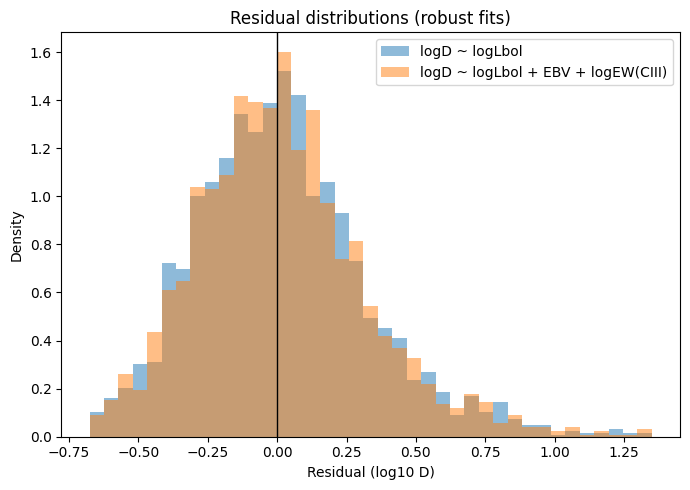

In [56]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

assert "results_table" in globals(), "results_table not found."

# --- Robust IRLS for multiple regressors ---

def irls_robust(X, y, loss="huber", c=1.345, max_iter=100, tol=1e-8):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)

    for _ in range(max_iter):
        r = y - X @ beta
        mad = np.median(np.abs(r - np.median(r)))
        s = 1.4826 * mad if mad > 0 else np.std(r)
        if not np.isfinite(s) or s <= 0:
            s = np.std(r) if np.std(r) > 0 else 1.0

        u = r / s
        if loss.lower() == "huber":
            w = np.ones_like(u)
            au = np.abs(u)
            mask_big = au > c
            w[mask_big] = c / au[mask_big]
        elif loss.lower() == "tukey":
            w = np.zeros_like(u)
            au = np.abs(u)
            mask_in = au < c
            t = u[mask_in] / c
            w[mask_in] = (1 - t**2) ** 2
        else:
            raise ValueError("loss must be 'huber' or 'tukey'")

        W = np.sqrt(w)
        Xw = X * W[:, None]
        yw = y * W
        beta_new, *_ = np.linalg.lstsq(Xw, yw, rcond=None)

        if np.max(np.abs(beta_new - beta)) < tol:
            beta = beta_new
            break
        beta = beta_new

    return beta

# --- Load base quantities ---
logD = np.array(results_table["logD_post"], dtype=float) / np.log(10.0)
logL = np.array(results_table["wushen_loglbol"], dtype=float)
sid = np.array(results_table["source_id"], dtype=np.int64)

CAT_PATH = os.path.expanduser("data/sdss_gaia_catalog_for_ztf_gaia_lc_with_wushen_vac_2024.fits")

with fits.open(CAT_PATH, memmap=True) as hdul:
    data = hdul[1].data
    names = set(data.names)

    if "wushen_ebv" not in names:
        raise KeyError("wushen_ebv not found in catalog")
    if "wushen_ciii_all" not in names:
        raise KeyError("wushen_ciii_all not found in catalog")

    cat_sid = np.array(data["source_id"], dtype=np.int64)
    order = np.argsort(cat_sid)
    cat_sid_sorted = cat_sid[order]
    pos = np.searchsorted(cat_sid_sorted, sid)
    ok = (pos < len(cat_sid_sorted)) & (cat_sid_sorted[pos] == sid)
    row_idx = order[pos[ok]]

    ebv = np.full(len(sid), np.nan, dtype=float)
    ebv[ok] = np.array(data["wushen_ebv"][row_idx], dtype=float)

    # CIII] EW is index 5 in line array: [peak, centroid, flux, logL, FWHM, EW]
    arr = data["wushen_ciii_all"]
    ciii_ew = np.full(len(sid), np.nan, dtype=float)
    if arr.dtype.kind == "O":
        vals = arr[row_idx]
        ciii_ew[ok] = np.array(
            [v[5] if (v is not None and len(v) > 5) else np.nan for v in vals],
            dtype=float,
        )
    else:
        a = np.array(arr, dtype=float)
        if a.ndim < 2 or a.shape[1] <= 5:
            raise ValueError("wushen_ciii_all array does not have EW index 5")
        ciii_ew[ok] = a[row_idx, 5]

# --- Build analysis mask (same for both models) ---
mask = np.isfinite(logD) & np.isfinite(logL) & np.isfinite(ebv) & np.isfinite(ciii_ew)
mask &= (ciii_ew > 0) & (ciii_ew <= 200)

logD = logD[mask]
logL = logL[mask]
ebv = ebv[mask]
logew = np.log10(ciii_ew[mask])

n = len(logD)
print("N used:", n)

# Center predictors for stability
logL0 = logL - np.median(logL)
ebv0 = ebv - np.median(ebv)
logew0 = logew - np.median(logew)

# --- Model 1: logD ~ logLbol ---
X1 = np.column_stack([np.ones(n), logL0])
b1 = irls_robust(X1, logD, loss="huber")
res1 = logD - X1 @ b1

# --- Model 2: logD ~ logLbol + EBV + logEW(CIII) ---
X2 = np.column_stack([np.ones(n), logL0, ebv0, logew0])
b2 = irls_robust(X2, logD, loss="huber")
res2 = logD - X2 @ b2

print("Model 1 coeffs [a, b_L]:", b1)
print("Model 2 coeffs [a, b_L, b_EBV, b_logEW]:", b2)
print("Residual std (model1):", np.std(res1))
print("Residual std (model2):", np.std(res2))

# --- Plot residual distributions ---
all_res = np.concatenate([res1, res2])
lo, hi = np.nanpercentile(all_res, [1, 99])
bins = np.linspace(lo, hi, 40)

plt.figure(figsize=(7, 5))
plt.hist(res1, bins=bins, density=True, alpha=0.5, label="logD ~ logLbol")
plt.hist(res2, bins=bins, density=True, alpha=0.5, label="logD ~ logLbol + EBV + logEW(CIII)")
plt.axvline(0.0, color="k", lw=1)
plt.xlabel("Residual (log10 D)")
plt.ylabel("Density")
plt.title("Residual distributions (robust fits)")
plt.legend()
plt.tight_layout()
plt.show()


In [58]:
import numpy as np

# Expect these from the previous cell; recompute if missing
required = ["logD", "logL0", "ebv0", "logew0"]
if not all(name in globals() for name in required):
    raise RuntimeError("Run the EBV+CIII robust-fit cell first to define logD/logL0/ebv0/logew0.")

# Robust IRLS helper (repeat here for CV)
def irls_robust(X, y, loss="huber", c=1.345, max_iter=100, tol=1e-8):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)

    for _ in range(max_iter):
        r = y - X @ beta
        mad = np.median(np.abs(r - np.median(r)))
        s = 1.4826 * mad if mad > 0 else np.std(r)
        if not np.isfinite(s) or s <= 0:
            s = np.std(r) if np.std(r) > 0 else 1.0

        u = r / s
        if loss.lower() == "huber":
            w = np.ones_like(u)
            au = np.abs(u)
            mask_big = au > c
            w[mask_big] = c / au[mask_big]
        elif loss.lower() == "tukey":
            w = np.zeros_like(u)
            au = np.abs(u)
            mask_in = au < c
            t = u[mask_in] / c
            w[mask_in] = (1 - t**2) ** 2
        else:
            raise ValueError("loss must be 'huber' or 'tukey'")

        W = np.sqrt(w)
        Xw = X * W[:, None]
        yw = y * W
        beta_new, *_ = np.linalg.lstsq(Xw, yw, rcond=None)

        if np.max(np.abs(beta_new - beta)) < tol:
            beta = beta_new
            break
        beta = beta_new

    return beta

# --- Build design matrices ---
logD = np.asarray(logD, dtype=float)
logL0 = np.asarray(logL0, dtype=float)
ebv0 = np.asarray(ebv0, dtype=float)
logew0 = np.asarray(logew0, dtype=float)

n = len(logD)
X1 = np.column_stack([np.ones(n), logL0])
X2 = np.column_stack([np.ones(n), logL0, ebv0, logew0])

# --- Delta variance (full sample, using existing residuals if present) ---
if "res1" in globals() and "res2" in globals():
    r1 = np.asarray(res1, dtype=float)
    r2 = np.asarray(res2, dtype=float)
    if len(r1) != n or len(r2) != n:
        r1 = logD - X1 @ irls_robust(X1, logD, loss="huber")
        r2 = logD - X2 @ irls_robust(X2, logD, loss="huber")
else:
    r1 = logD - X1 @ irls_robust(X1, logD, loss="huber")
    r2 = logD - X2 @ irls_robust(X2, logD, loss="huber")

var1 = np.var(r1, ddof=1)
var2 = np.var(r2, ddof=1)
delta_var = (var1 - var2) / var1 if var1 > 0 else np.nan

print("Delta variance (1 -> 2):", delta_var)

# --- Cross-validated RMSE ---
def cv_rmse(X, y, k=5, seed=0):
    n = len(y)
    if n < k:
        raise ValueError("Not enough samples for CV")
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    folds = np.array_split(idx, k)
    rmses = []

    for f in folds:
        train_idx = np.setdiff1d(idx, f, assume_unique=False)
        Xtr, ytr = X[train_idx], y[train_idx]
        Xte, yte = X[f], y[f]
        beta = irls_robust(Xtr, ytr, loss="huber")
        yhat = Xte @ beta
        rmse = np.sqrt(np.mean((yte - yhat) ** 2))
        rmses.append(rmse)

    return np.mean(rmses), np.std(rmses)

rmse1_mean, rmse1_std = cv_rmse(X1, logD, k=5, seed=0)
rmse2_mean, rmse2_std = cv_rmse(X2, logD, k=5, seed=0)

print(f"CV RMSE model1: {rmse1_mean:.5f} +/- {rmse1_std:.5f}")
print(f"CV RMSE model2: {rmse2_mean:.5f} +/- {rmse2_std:.5f}")


Delta variance (1 -> 2): 0.03625033204656532


/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/4195380452.py:15: RuntimeWarning: divide by zero encountered in matmul
  r = y - X @ beta
/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/4195380452.py:15: RuntimeWarning: overflow encountered in matmul
  r = y - X @ beta
/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/4195380452.py:15: RuntimeWarning: invalid value encountered in matmul
  r = y - X @ beta
/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/4195380452.py:90: RuntimeWarning: divide by zero encountered in matmul
  yhat = Xte @ beta
/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/4195380452.py:90: RuntimeWarning: overflow encountered in matmul
  yhat = Xte @ beta
/var/folders/jb/7f0bq_sx0435s1wvlt2yfkcr0000gn/T/ipykernel_10708/4195380452.py:90: RuntimeWarning: invalid value encountered in matmul
  yhat = Xte @ beta


CV RMSE model1: 0.37853 +/- 0.04249
CV RMSE model2: 0.37209 +/- 0.04011
